In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import scienceplots
plt.style.use(['science', 'no-latex'])

from utils import quality_metrics
# Import the display functions
from utils.display_metrics_table import (
    display_metrics_table, 
    print_metrics_summary
)

# Allow more columns to be displayed
pd.set_option("display.max_columns", None)

import logging
logging.basicConfig(level=logging.WARNING)

IMAGES_PATH = "/Users/klemenkubelj/Documents/school/graduate/masters/code/cvar-masters-thesis-2025/figures"

In [3]:
plt.rcParams.update({
    'font.size': 14,          # General font size
    'axes.titlesize': 16,     # Title font size
    'axes.labelsize': 14,     # X and Y label font size
    'xtick.labelsize': 14,    # X-axis tick label size
    'ytick.labelsize': 14,    # Y-axis tick label size
    'legend.fontsize': 12,    # Legend font size
    'figure.titlesize': 18,    # Figure title (suptitle) font size

    "axes.axisbelow": True
})

In [4]:
!which python

/Users/klemenkubelj/miniconda3/envs/cvar-masters/bin/python


In [5]:
events = [
    2010,
    2012,
    2014,
    2023,
]

In [6]:
# df = pd.read_excel(os.path.join("../data/predicted_flood_depths_with_water_distance_2025-05-13.xlsx"))
df = pd.read_excel(os.path.join("../data/predicted_flood_depths_with_water_distance_2025-10-26.xlsx"))
df = df[
    df["measured_depth"]<4
]
# Cap measured_depth at 4m
# df["measured_depth"] = df["measured_depth"].clip(upper=4)
# df.shape
# Replace 0 values with 0.01 for all measured_depth
# df["measured_depth"] = df["measured_depth"].replace(0, 0.01)

# Set DogeodekLabel columns
_map = {
    14: 2010,
    18: 2012,
    24: 2014,
    68: 2023,
}
df["DogodekLabel"] = df["DogodekId"].map(_map)

In [7]:
# Geopandas DF
def to_gdf(df):
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.gps_lng, df.gps_lat))
    gdf.crs = {'init': 'epsg:4326'}
    gdf = gdf.to_crs(epsg=3974)
    gdf["geometry"] = gdf.geometry.centroid
    return gdf

In [8]:
df = df[[
    "VlogaId",
    "DogodekId",
    "DogodekLabel",
    "gps_lat",
    "gps_lng",
    "measured_depth",
    "predicted_wri_depth",
    "predicted_si_depth",
    "predicted_si_depth_100r",
    "predicted_si_depth_1000r",
    "distance_to_water",
]]

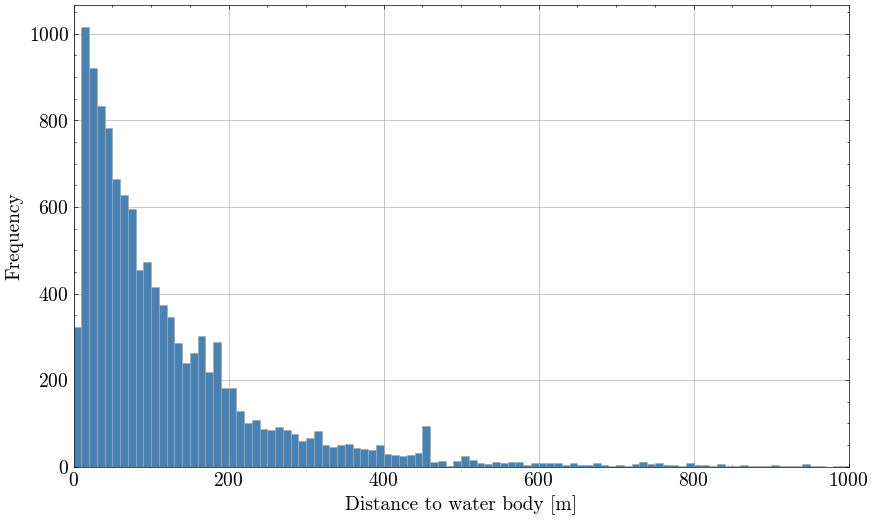

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(df["distance_to_water"], edgecolor="darkgrey", color="steelblue", linewidth=0.5, bins=np.linspace(0, 1000, 101))
plt.xlabel("Distance to water body [m]")
plt.ylabel("Frequency")
plt.grid(True)
plt.xlim(0,1000)

# plt.savefig(IMAGES_PATH + "/05/water_proximity_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()

([<matplotlib.axis.XTick at 0x175164c40>,
 [Text(0.5, 0, '$\\mathdefault{0.5}$'),
  Text(1.0, 0, '$\\mathdefault{1.0}$'),
  Text(1.5, 0, '$\\mathdefault{1.5}$'),
  Text(2.0, 0, '$\\mathdefault{2.0}$'),
  Text(2.5, 0, '$\\mathdefault{2.5}$'),
  Text(3.0, 0, '$\\mathdefault{3.0}$'),
  Text(3.5, 0, '$\\mathdefault{3.5}$'),
  Text(4.0, 0, '$\\mathdefault{4.0}$')])

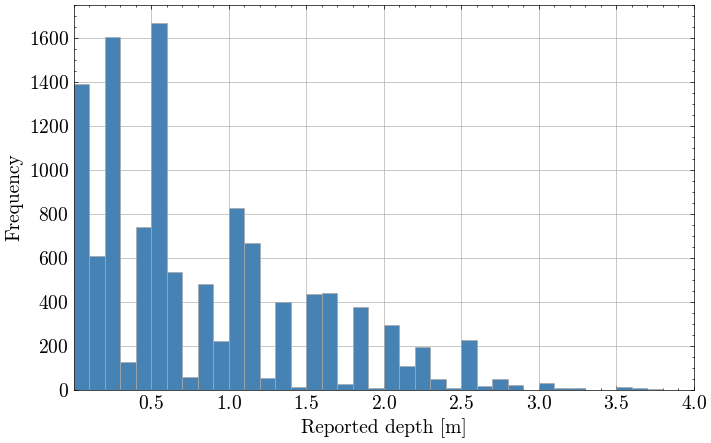

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df["measured_depth"], edgecolor="darkgrey", color="steelblue", linewidth=0.5, bins=np.linspace(0, 4, 41))
plt.xlabel("Reported depth [m]")
plt.ylabel("Frequency")
plt.grid(True)
plt.xlim(0, 4)

# Set x-axis ticks at regular intervals (every 0.5m) to align with data
plt.xticks(np.arange(0.5, 4.5, 0.5))

# plt.show()
# plt.savefig(IMAGES_PATH + "/05/validation_depth_histogram.pdf", dpi=300, bbox_inches="tight")

In [11]:
# Show number of samples, split by event
event_sample_counts = df["DogodekLabel"].value_counts()
print("Number of samples split by event:")
print(event_sample_counts)

df.shape

Number of samples split by event:
DogodekLabel
2023    6568
2010    2477
2012    1797
2014     898
Name: count, dtype: int64


(11740, 11)

In [12]:
# Calculate the errors
# If df["predicted_si_depth"] is 0, set it to 0.5.
# df["predicted_si_depth"] = df["predicted_si_depth"].clip(lower=0.5)
df["si_error"] = df["predicted_si_depth"] - df["measured_depth"]
df["wri_error"] = df["predicted_wri_depth"] - df["measured_depth"]
df["si_error_100r"] = df["predicted_si_depth_100r"] - df["measured_depth"]
df["si_error_1000r"] = df["predicted_si_depth_1000r"] - df["measured_depth"]

# df = df[df["measured_depth"]>0]
df.shape

(11740, 15)

In [13]:
import rasterio
import geopandas as gpd
import pandas as pd
import numpy as np

# # Method 1: Simple approach - Sample the GeoTIFF data
# def open_geotiff_simple(geotiff_path, sample_factor=1):
#     """
#     Opens a GeoTIFF and creates a GeoDataFrame for visualization.
    
#     Args:
#         geotiff_path: Path to the GeoTIFF file
#         sample_factor: Downsample factor (1 = no downsampling, 2 = every 2nd pixel, etc.)
    
#     Returns:
#         GeoDataFrame with geometry and value columns
#     """
#     with rasterio.open(geotiff_path) as src:
#         # Read the data
#         data = src.read(1)
        
#         # Downsample for performance if needed
#         data = data[::sample_factor, ::sample_factor]
        
#         # Get coordinates for pixels with valid data (> 0)
#         rows, cols = np.where(data > 0)
        
#         # Convert pixel coordinates to geographic coordinates
#         xs, ys = rasterio.transform.xy(src.transform, rows * sample_factor, cols * sample_factor)
        
#         # Create DataFrame
#         df = pd.DataFrame({
#             'value': data[rows, cols],
#             'lon': xs,
#             'lat': ys
#         })
        
#         # Convert to GeoDataFrame
#         gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat))
#         gdf.crs = src.crs
        
#     return gdf

# def raster_to_polygons(geotiff_path, mask_value=0):
#     """
#     Converts a GeoTIFF to vector polygons (better for large datasets).
    
#     Args:
#         geotiff_path: Path to the GeoTIFF file
#         mask_value: Value to treat as no-data (will be excluded)
    
#     Returns:
#         GeoDataFrame with polygon geometries
#     """
#     import rasterio.features
#     from shapely.geometry import shape
    
#     with rasterio.open(geotiff_path) as src:
#         # Read the data
#         data = src.read(1)
        
#         # Create a mask for valid data
#         mask = data != mask_value
        
#         # Convert raster to polygons - returns list of (geometry, value) tuples
#         shapes = list(rasterio.features.shapes(data, mask=mask, transform=src.transform))
        
#         # Convert to GeoJSON-like format for GeoDataFrame.from_features()
#         features = []
#         for geometry_dict, value in shapes:
#             features.append({
#                 'type': 'Feature',
#                 'geometry': geometry_dict,
#                 'properties': {'value': value}
#             })
        
#         # Create GeoDataFrame
#         gdf = gpd.GeoDataFrame.from_features(
#             features,
#             crs=src.crs
#         )
        
#     return gdf

def raster_to_squares(geotiff_path, sample_factor=1):
    """
    Converts a GeoTIFF to a GeoDataFrame with square polygons representing each pixel.
    
    Args:
        geotiff_path: Path to the GeoTIFF file
        sample_factor: Downsample factor (1 = no downsampling, 2 = every 2nd pixel, etc.)
    
    Returns:
        GeoDataFrame with square polygon geometries
    """
    import rasterio.features
    from shapely.geometry import box
    
    with rasterio.open(geotiff_path) as src:
        # Read the data
        data = src.read(1)

        # Print CRS info for debugging
        print(f"Source CRS: {src.crs}")
        
        # Downsample if needed
        data = data[::sample_factor, ::sample_factor]
        
        # Get the pixel size
        pixel_size_x, pixel_size_y = abs(src.transform.a), abs(src.transform.e)
        pixel_size_x *= sample_factor
        pixel_size_y *= sample_factor
        
        # Get transform
        transform = src.transform
        
        # Create polygons for each pixel with value > 0
        polygons = []
        values = []
        
        for row in range(data.shape[0]):
            for col in range(data.shape[1]):
                value = data[row, col]
                if value > 0:  # Only create polygons for non-zero values
                    # Convert row/col to geographic coordinates
                    x, y = rasterio.transform.xy(transform, row * sample_factor, col * sample_factor)
                    
                    # Create a square polygon (box) for this pixel
                    half_pixel_x = pixel_size_x / 2
                    half_pixel_y = pixel_size_y / 2
                    
                    square = box(
                        x - half_pixel_x,  # left
                        y - half_pixel_y,  # bottom
                        x + half_pixel_x,  # right
                        y + half_pixel_y   # top
                    )
                    
                    polygons.append(square)
                    values.append(value)
        
        # Create GeoDataFrame
        gdf = gpd.GeoDataFrame({'value': values}, geometry=polygons, crs=src.crs)

    # Set crs to 3974
    gdf = gdf.to_crs(epsg=3974)
        
    return gdf

In [14]:
# tiff_gdf_10 = raster_to_squares("/Users/klemenkubelj/Documents/school/graduate/masters/data/si_karte_globin/merged_v2/globine_q100_10.tif")
# tiff_gdf_100 = raster_to_squares("/Users/klemenkubelj/Documents/school/graduate/masters/data/si_karte_globin/merged_v2/globine_q100_100.tif")
# tiff_gdf_1000 = raster_to_squares("/Users/klemenkubelj/Documents/school/graduate/masters/data/si_karte_globin/merged_v2/globine_q100_1000.tif")

In [15]:
# order by max si_error_100r
_df = df.sort_values(by="si_error", ascending=False)[df["measured_depth"]>0][[
    "gps_lat",
    "gps_lng",
    "measured_depth",
    "predicted_wri_depth",
    "predicted_si_depth",
    "predicted_si_depth_100r",
    "predicted_si_depth_1000r",
]].head(100)

gdf = to_gdf(_df)

/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_64929/3718120452.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  _df = df.sort_values(by="si_error", ascending=False)[df["measured_depth"]>0][[
/Users/klemenkubelj/miniconda3/envs/cvar-masters/lib/python3.10/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [16]:
m = gdf.explore(
    color="red",
)

# tiff_gdf_100.explore(
#     m=m,
#     column="value",
#     cmap="viridis",
#     legend=True,
#     categorical=True,
#     legend_kwds={
#         "caption": "Flood depth [m]",
#     },
# )
m

### Segmentation by flood event

In [17]:
print(f"Total")
_df = df.copy()
# _df = _df[_df["distance_to_water"]<100]
print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth"]))
print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth"]))
print("-"*100)

for event_label in events:
    print(f"Event: {event_label}")
    _df = df.copy()
    _df = _df[_df["DogodekLabel"]==event_label]
    # _df = _df[_df["distance_to_water"]<100]
    print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth"]))
    print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth"]))
    print("-"*100)

Total
{'within_20': 0.1882, 'median_error': -0.25, 'mean_error': -0.2314, 'median_absolute_error': 0.5, 'RMSE': 0.954, 'st_dev_residuals': 0.9255, 'total_samples': 11740}
{'within_20': 0.1175, 'median_error': -0.5118, 'mean_error': -0.7238, 'median_absolute_error': 0.6, 'RMSE': 1.0429, 'st_dev_residuals': 0.7508, 'total_samples': 11740}
----------------------------------------------------------------------------------------------------
Event: 2010
{'within_20': 0.3383, 'median_error': 0.35, 'mean_error': 0.3295, 'median_absolute_error': 0.5, 'RMSE': 0.9516, 'st_dev_residuals': 0.8929, 'total_samples': 2477}
{'within_20': 0.2794, 'median_error': -0.35, 'mean_error': -0.4929, 'median_absolute_error': 0.35, 'RMSE': 0.7712, 'st_dev_residuals': 0.5933, 'total_samples': 2477}
----------------------------------------------------------------------------------------------------
Event: 2012
{'within_20': 0.3267, 'median_error': 0.0, 'mean_error': -0.0977, 'median_absolute_error': 0.5, 'RMSE': 0.

In [18]:
# Generate LaTeX table from regression metrics
def format_latex_table(df, events):
    """
    Generate LaTeX table from regression performance metrics.
    """
    results = []
    
    # Process each event
    for event_label in events:
        _df = df.copy()
        _df = _df[_df["DogodekLabel"] == event_label]
        
        # Calculate metrics for SI IKG model
        si_metrics = quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth"])
        
        # Calculate metrics for WRI Aqueduct model  
        wri_metrics = quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth"])
        
        # Store results
        results.append({
            'event': event_label,
            'model': 'SI IKG',
            'me': si_metrics['mean_error'],
            'rmse': si_metrics['RMSE'],
            'sigma': si_metrics['st_dev_residuals'],
            'p20': si_metrics['within_20'] * 100
        })
        
        results.append({
            'event': event_label,
            'model': 'WRI Aqueduct',
            'me': wri_metrics['mean_error'],
            'rmse': wri_metrics['RMSE'],
            'sigma': wri_metrics['st_dev_residuals'],
            'p20': wri_metrics['within_20'] * 100
        })
    
    # Calculate total metrics
    si_total_metrics = quality_metrics.get_metrics(df["measured_depth"], df["predicted_si_depth"])
    wri_total_metrics = quality_metrics.get_metrics(df["measured_depth"], df["predicted_wri_depth"])
    
    results.append({
        'event': 'Total',
        'model': 'SI IKG',
        'me': si_total_metrics['mean_error'],
        'rmse': si_total_metrics['RMSE'],
        'sigma': si_total_metrics['st_dev_residuals'],
        'p20': si_total_metrics['within_20'] * 100
    })
    
    results.append({
        'event': 'Total',
        'model': 'WRI Aqueduct',
        'me': wri_total_metrics['mean_error'],
        'rmse': wri_total_metrics['RMSE'],
        'sigma': wri_total_metrics['st_dev_residuals'],
        'p20': wri_total_metrics['within_20'] * 100
    })
    
    # Generate LaTeX table
    latex_table = """\\begin{table}[htb]
    \\centering
    \\caption{Regression performance metrics for all flood events.}
    \\label{tab:regression-results-raw}
    \\begin{tabular}{|l|l|c|c|c|c|}
        \\hline
        \\textbf{Event} & \\textbf{Model} & \\textbf{ME} & \\textbf{RMSE} & \\textbf{$\\sigma$} & \\textbf{$P_{20}$} \\\\
        \\hline"""
    
    # Process results and format table rows
    current_event = None
    for result in results:
        event = result['event']
        model = result['model']
        me = result['me']
        rmse = result['rmse']
        sigma = result['sigma']
        p20 = result['p20']
        
        # Format numbers
        me_str = f"{me:+.2f}" if event != 'Total' else f"\\textbf{{{me:+.2f}}}"
        rmse_str = f"{rmse:.3f}" if event != 'Total' else f"\\textbf{{{rmse:.3f}}}"
        sigma_str = f"{sigma:.3f}" if event != 'Total' else f"\\textbf{{{sigma:.3f}}}"
        p20_str = f"{p20:.2f}\\%" if event != 'Total' else f"\\textbf{{{p20:.2f}\\%}}"
        
        if event != current_event:
            if current_event is not None:
                latex_table += " \\\\\n        \\hline"
            
            if event == 'Total':
                latex_table += f"\n        \\multirow{{2}}{{*}}{{\\textbf{{{event}}}}} & \\textbf{{{model}}} & {me_str} & {rmse_str} & {sigma_str} & {p20_str}"
            else:
                latex_table += f"\n        \\multirow{{2}}{{*}}{{{event}}} & {model} & {me_str} & {rmse_str} & {sigma_str} & {p20_str}"
            current_event = event
        else:
            if event == 'Total':
                latex_table += f" \\\\\n        & \\textbf{{{model}}} & {me_str} & {rmse_str} & {sigma_str} & {p20_str}"
            else:
                latex_table += f" \\\\\n        & {model} & {me_str} & {rmse_str} & {sigma_str} & {p20_str}"
    
    latex_table += """ \\\\
        \\hline
    \\end{tabular}
\\end{table}"""
    
    return latex_table

# Generate the table
events = [2010, 2012, 2014, 2023]
latex_output = format_latex_table(df, events)
print(latex_output)

\begin{table}[htb]
    \centering
    \caption{Regression performance metrics for all flood events.}
    \label{tab:regression-results-raw}
    \begin{tabular}{|l|l|c|c|c|c|}
        \hline
        \textbf{Event} & \textbf{Model} & \textbf{ME} & \textbf{RMSE} & \textbf{$\sigma$} & \textbf{$P_{20}$} \\
        \hline
        \multirow{2}{*}{2010} & SI IKG & +0.33 & 0.952 & 0.893 & 33.83\% \\
        & WRI Aqueduct & -0.49 & 0.771 & 0.593 & 27.94\% \\
        \hline
        \multirow{2}{*}{2012} & SI IKG & -0.10 & 0.997 & 0.993 & 32.67\% \\
        & WRI Aqueduct & -0.56 & 0.943 & 0.761 & 26.32\% \\
        \hline
        \multirow{2}{*}{2014} & SI IKG & -0.08 & 0.677 & 0.672 & 13.25\% \\
        & WRI Aqueduct & -0.37 & 0.526 & 0.372 & 10.36\% \\
        \hline
        \multirow{2}{*}{2023} & SI IKG & -0.50 & 0.975 & 0.837 & 10.12\% \\
        & WRI Aqueduct & -0.90 & 1.200 & 0.788 & 1.86\% \\
        \hline
        \multirow{2}{*}{\textbf{Total}} & \textbf{SI IKG} & \textbf{-0.23} & \t

In [19]:
def plot_errors_histogram(df, true_column, predicted_column, title: str = "Histogram of Errors", ax=None):
    if ax is None:
        ax = plt.gca()
        
    errors = df[predicted_column] - df[true_column]
    ax.hist(errors, bins=30, edgecolor="darkgrey", color="steelblue", linewidth=0.5)
    ax.set_title(f"{title}", fontsize=14)
    ax.set_xlabel("Error [m]", fontsize=14)
    ax.set_ylabel("Frequency", fontsize=14)
    ax.grid(alpha=1)
    
    median_error = errors.median()
    mean_error = errors.mean()
    mae_error = np.mean(abs(errors))
    rmse_error = np.sqrt(np.mean(errors**2))
    std_error = errors.std()
    ax.axvline(mean_error, color="red", linestyle="dashed", linewidth=1)
    # ax.axvline(0, color="darkgrey", linestyle="solid", linewidth=1)  # Draw a line at x=0
    
    # Set x-axis limits to ensure 0 is in the middle
    max_abs_error = max(abs(errors.min()), abs(errors.max()))
    ax.set_xlim(-max_abs_error, max_abs_error)
    
    # Get the current axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Place text in top right corner
    # stats_text = f"Median: {median_error:.2f}\nMean: {mean_error:.2f}\nMAE: {mae_error:.2f}\nRMSE: {rmse_error:.2f}\nStd: {std_error:.2f}"
    # ax.text(
    #     xlim[1] * 0.95,  # x position (95% of the way to the right)
    #     ylim[1] * 0.95,  # y position (95% of the way to the top)
    #     stats_text,
    #     color="red",
    #     ha="right",  # horizontal alignment
    #     va="top",    # vertical alignment
    #     bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2)  # white background box
    # )
    print(f"{title} Mean: {mean_error:.4f}")

In [20]:
# _df = df.copy()
# _df = _df[_df["DogodekLabel"]==2023]
# _df["si_error"].mean()

SI IKG Prediction Errors - Event 2010 Mean: 0.3295
SI IKG Prediction Errors - Event 2012 Mean: -0.0977
SI IKG Prediction Errors - Event 2014 Mean: -0.0828
SI IKG Prediction Errors - Event 2023 Mean: -0.4998


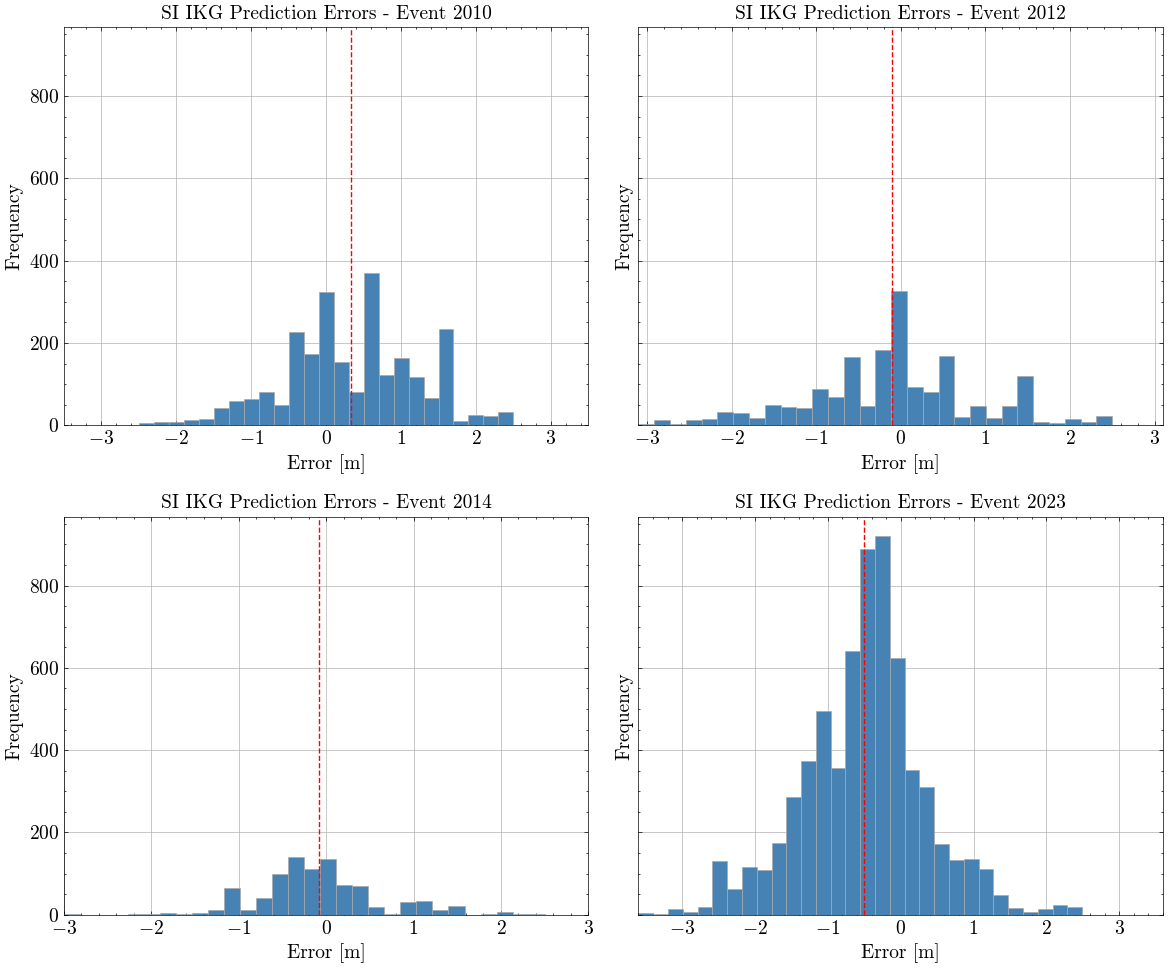

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

for idx, event_label in enumerate(events):
    row = idx // 2
    col = idx % 2
    _df = df.copy()
    _df = _df[_df["DogodekLabel"]==event_label]
    # _df = _df[_df["distance_to_water"]<50]
    plot_errors_histogram(
        _df,
        "measured_depth",
        "predicted_si_depth",
        title=f"SI IKG Prediction Errors - Event {event_label}",
        ax=axes[row, col]
    )

plt.tight_layout()
# plt.savefig(IMAGES_PATH + "/05/si_ikg_bias_histograms.pdf", dpi=300, bbox_inches="tight")
plt.show()

Measured Depth - Predicted SI Depth Mean: -0.2314


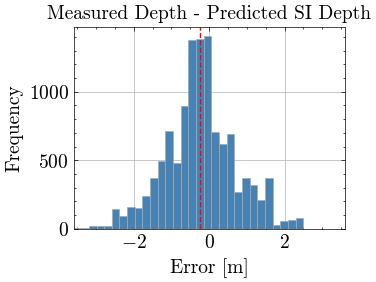

In [22]:
plot_errors_histogram(df, "measured_depth", "predicted_si_depth", title="Measured Depth - Predicted SI Depth")

WRI Prediction Errors - Event 2010 Mean: -0.4929
WRI Prediction Errors - Event 2012 Mean: -0.5567
WRI Prediction Errors - Event 2014 Mean: -0.3728
WRI Prediction Errors - Event 2023 Mean: -0.9046


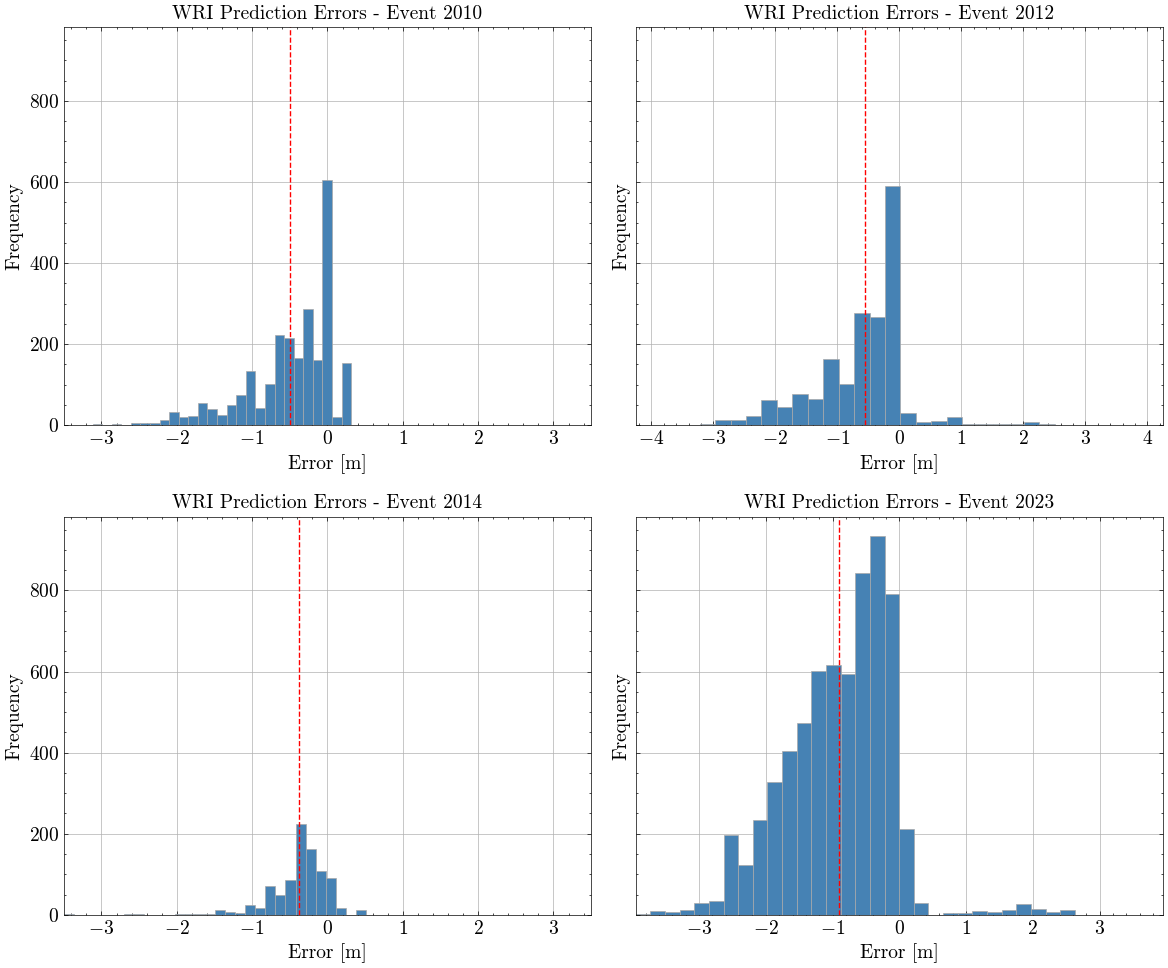

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

for idx, event_label in enumerate(events):
    row = idx // 2
    col = idx % 2
    _df = df.copy()
    _df = _df[_df["DogodekLabel"]==event_label]
    # _df = _df[_df["distance_to_water"]<50]
    plot_errors_histogram(
        _df,
        "measured_depth",
        "predicted_wri_depth",
        title=f"WRI Prediction Errors - Event {event_label}",
        ax=axes[row, col]
    )

plt.tight_layout()
# plt.savefig(IMAGES_PATH + "/05/wri_bias_histograms.pdf", dpi=300, bbox_inches="tight")
plt.show()

Measured Depth - Predicted WRI Depth Mean: -0.7238


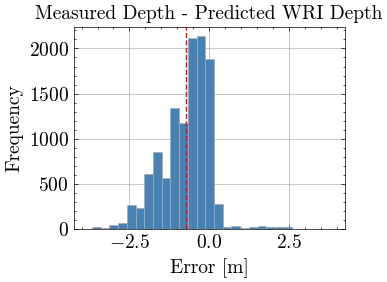

In [24]:
plot_errors_histogram(df, "measured_depth", "predicted_wri_depth", title="Measured Depth - Predicted WRI Depth")

# Bias-adjusted columns

In [25]:
df.head()

,VlogaId,DogodekId,DogodekLabel,gps_lat,gps_lng,measured_depth,predicted_wri_depth,predicted_si_depth,predicted_si_depth_100r,predicted_si_depth_1000r,distance_to_water,si_error,wri_error,si_error_100r,si_error_1000r
0,147651,14,2010,45.555094,13.786126,0.3,0.000000,1.5,0.5,1.5,51.774728,1.2,-0.300000,0.2,1.2
1,147686,14,2010,45.554893,13.785861,0.5,0.000000,0.5,0.5,1.5,77.397335,0.0,-0.500000,0.0,1.0
2,147692,14,2010,45.554893,13.785861,0.5,0.000000,0.5,0.5,1.5,77.397335,0.0,-0.500000,0.0,1.0
3,147704,14,2010,45.555094,13.786126,0.4,0.000000,1.5,0.5,1.5,51.774728,1.1,-0.400000,0.1,1.1
4,147723,14,2010,45.562016,13.756194,1.3,0.482443,2.5,2.5,2.5,455.622715,1.2,-0.817557,1.2,1.2


In [26]:
df["predicted_si_depth_bias_adjusted"] = df.groupby("DogodekId").apply(
    lambda x: (x["predicted_si_depth"] - (x["si_error"]).mean()).clip(lower=0)
).reset_index(level=0, drop=True)


df["predicted_wri_depth_bias_adjusted"] = df.groupby("DogodekId").apply(
    lambda x: (x["predicted_wri_depth"] - (x["wri_error"]).mean()).clip(lower=0)
).reset_index(level=0, drop=True)

In [27]:
df.tail(20)

,VlogaId,DogodekId,DogodekLabel,gps_lat,gps_lng,measured_depth,predicted_wri_depth,predicted_si_depth,predicted_si_depth_100r,predicted_si_depth_1000r,distance_to_water,si_error,wri_error,si_error_100r,si_error_1000r,predicted_si_depth_bias_adjusted,predicted_wri_depth_bias_adjusted
13508,1456697,68,2023,46.255995,15.099222,0.70,0.238227,0.0,0.0,0.0,74.629669,-0.70,-0.461773,-0.70,-0.70,0.499761,1.142834
13510,1456701,68,2023,46.186888,14.598643,1.90,0.000000,0.5,1.5,0.0,143.901461,-1.40,-1.900000,-0.40,-1.90,0.999761,0.904607
13512,1456703,68,2023,46.260228,15.092671,0.25,0.238227,0.0,0.0,0.0,244.549893,-0.25,-0.011773,-0.25,-0.25,0.499761,1.142834
13513,1456705,68,2023,46.136919,14.558394,0.60,0.000000,0.0,0.0,0.0,101.085842,-0.60,-0.600000,-0.60,-0.60,0.499761,0.904607
13514,1456708,68,2023,46.190071,14.547735,0.70,0.000000,0.5,0.5,0.5,23.593666,-0.20,-0.700000,-0.20,-0.20,0.999761,0.904607
13515,1456709,68,2023,46.187731,14.597833,0.70,0.000000,1.5,1.5,0.0,217.603060,0.80,-0.700000,0.80,-0.70,1.999761,0.904607
13516,1456717,68,2023,46.241212,15.192853,0.05,0.238227,0.5,1.5,1.5,27.935236,0.45,0.188227,1.45,1.45,0.999761,1.142834
13517,1456721,68,2023,46.244532,15.190517,0.35,0.238227,0.0,0.5,1.5,392.351381,-0.35,-0.111773,0.15,1.15,0.499761,1.142834
13518,1456729,68,2023,46.484655,14.874586,0.40,0.000000,0.0,0.0,0.0,20.200869,-0.40,-0.400000,-0.40,-0.40,0.499761,0.904607
13519,1456732,68,2023,46.485850,14.871476,1.20,0.000000,0.0,0.0,0.0,20.972077,-1.20,-1.200000,-1.20,-1.20,0.499761,0.904607


SI IKG Prediction Errors - Bias Adjusted - Event 2010 Mean: 0.0770
SI IKG Prediction Errors - Bias Adjusted - Event 2012 Mean: -0.0000
SI IKG Prediction Errors - Bias Adjusted - Event 2014 Mean: 0.0000
SI IKG Prediction Errors - Bias Adjusted - Event 2023 Mean: 0.0000


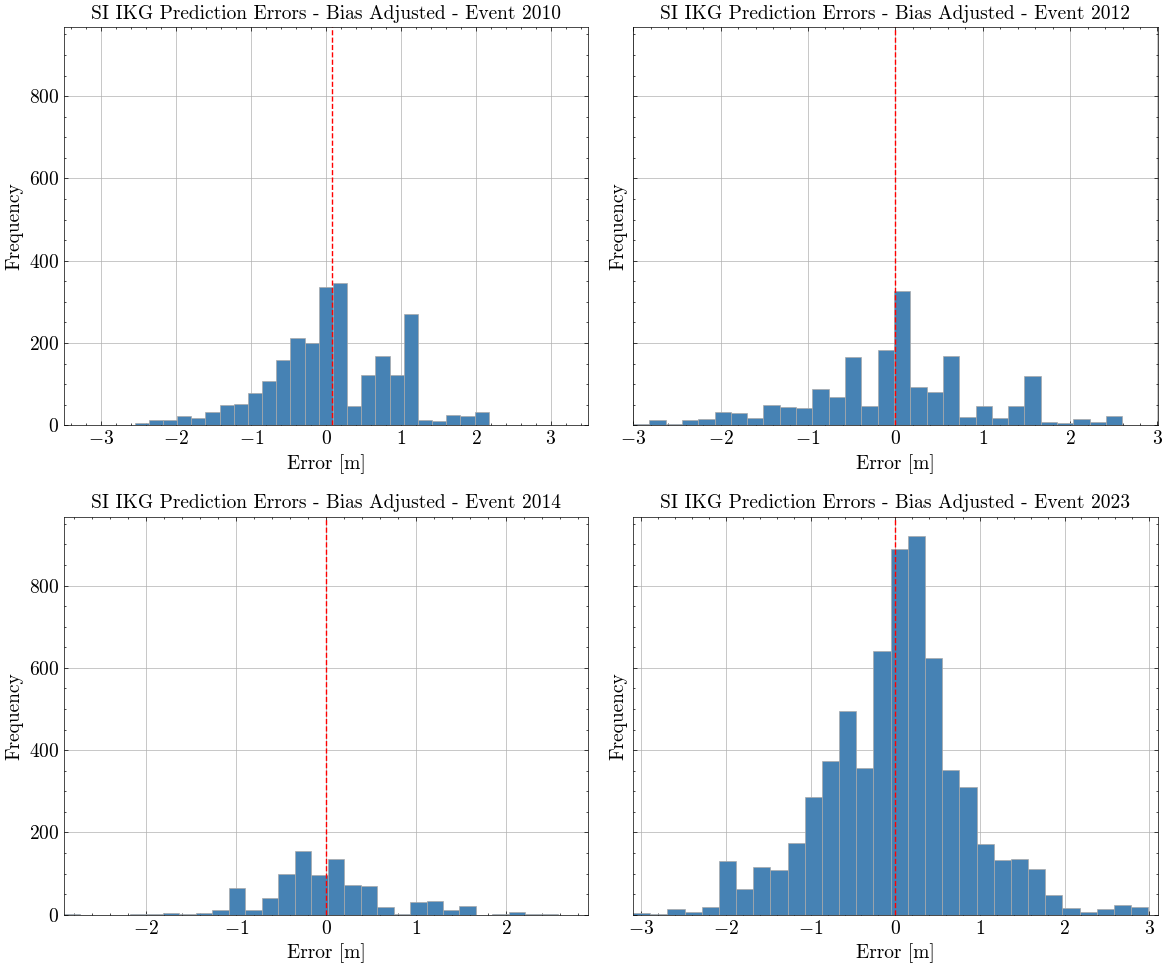

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

for idx, event_label in enumerate(events):
    row = idx // 2
    col = idx % 2
    _df = df.copy()
    _df = _df[_df["DogodekLabel"]==event_label]
    plot_errors_histogram(
        _df,
        "measured_depth",
        "predicted_si_depth_bias_adjusted",
        title=f"SI IKG Prediction Errors - Bias Adjusted - Event {event_label}",
        ax=axes[row, col]
    )

plt.tight_layout()
plt.show()

WRI Prediction Errors - Bias Adjusted - Event 2010 Mean: -0.0000
WRI Prediction Errors - Bias Adjusted - Event 2012 Mean: -0.0000
WRI Prediction Errors - Bias Adjusted - Event 2014 Mean: -0.0000
WRI Prediction Errors - Bias Adjusted - Event 2023 Mean: 0.0000


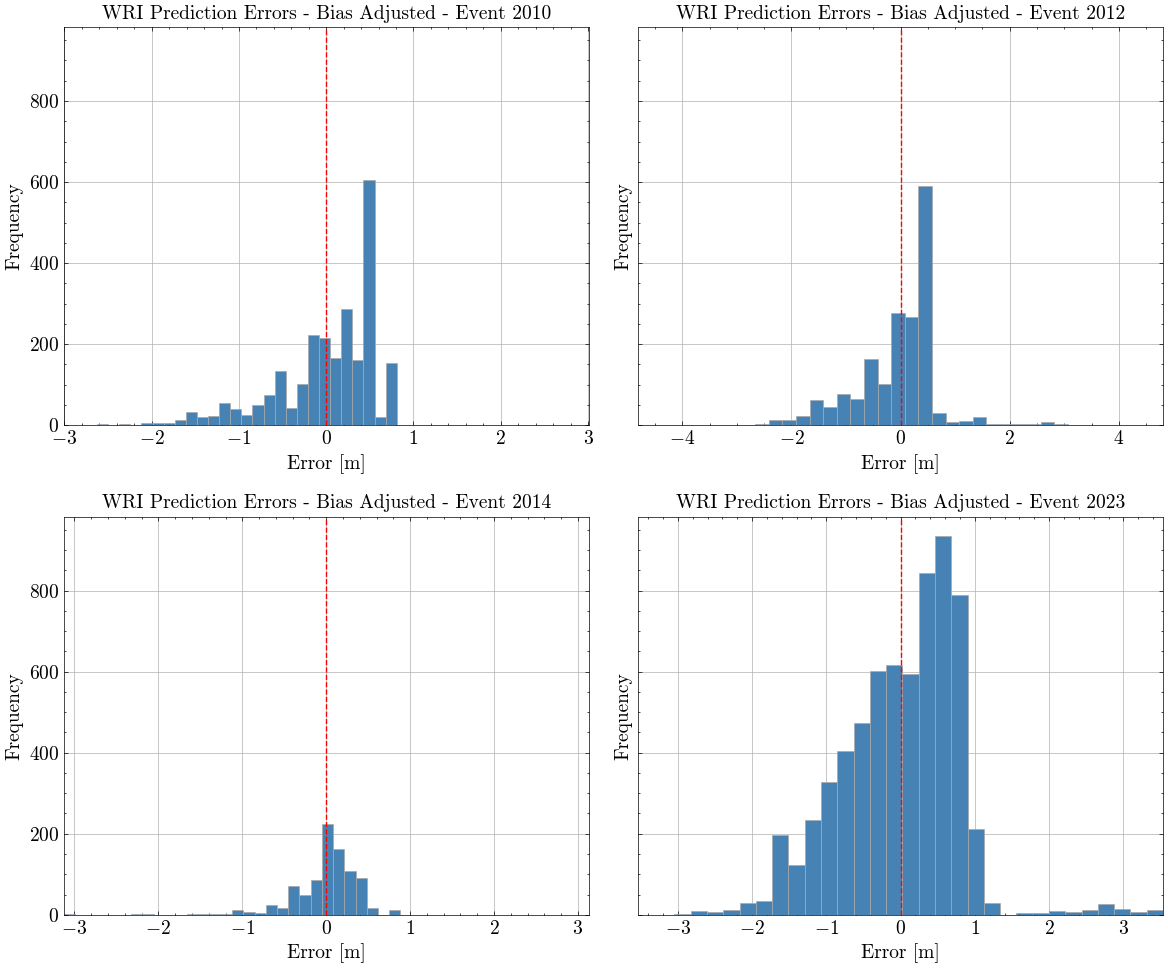

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

for idx, event_label in enumerate(events):
    row = idx // 2
    col = idx % 2
    _df = df.copy()
    _df = _df[_df["DogodekLabel"]==event_label]
    plot_errors_histogram(
        _df,
        "measured_depth",
        "predicted_wri_depth_bias_adjusted",
        title=f"WRI Prediction Errors - Bias Adjusted - Event {event_label}",
        ax=axes[row, col]
    )

plt.tight_layout()
plt.show()

In [30]:
_df = df.copy()
_df[_df["DogodekLabel"]==2010]

,VlogaId,DogodekId,DogodekLabel,gps_lat,gps_lng,measured_depth,predicted_wri_depth,predicted_si_depth,predicted_si_depth_100r,predicted_si_depth_1000r,distance_to_water,si_error,wri_error,si_error_100r,si_error_1000r,predicted_si_depth_bias_adjusted,predicted_wri_depth_bias_adjusted
0,147651,14,2010,45.555094,13.786126,0.3,0.000000,1.5,0.5,1.5,51.774728,1.2,-0.300000,0.2,1.2,1.170472,0.492904
1,147686,14,2010,45.554893,13.785861,0.5,0.000000,0.5,0.5,1.5,77.397335,0.0,-0.500000,0.0,1.0,0.170472,0.492904
2,147692,14,2010,45.554893,13.785861,0.5,0.000000,0.5,0.5,1.5,77.397335,0.0,-0.500000,0.0,1.0,0.170472,0.492904
3,147704,14,2010,45.555094,13.786126,0.4,0.000000,1.5,0.5,1.5,51.774728,1.1,-0.400000,0.1,1.1,1.170472,0.492904
4,147723,14,2010,45.562016,13.756194,1.3,0.482443,2.5,2.5,2.5,455.622715,1.2,-0.817557,1.2,1.2,2.170472,0.975347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2482,152841,14,2010,46.053673,14.116583,0.6,0.000000,0.5,0.5,0.5,146.594584,-0.1,-0.600000,-0.1,-0.1,0.170472,0.492904
2483,152882,14,2010,46.044490,14.107710,1.0,0.000000,0.0,0.5,0.5,63.925865,-1.0,-1.000000,-0.5,-0.5,0.000000,0.492904
2484,153043,14,2010,46.039510,14.131731,0.0,0.000000,0.5,1.5,0.5,16.349350,0.5,0.000000,1.5,0.5,0.170472,0.492904
2485,153113,14,2010,46.009324,14.128367,0.0,0.000000,0.5,0.5,1.5,11.764889,0.5,0.000000,0.5,1.5,0.170472,0.492904


# Regression total results

In [135]:
def plot_quality_metrics(df, events, bias_adjusted: bool = False, figtitle: str = None, si_resolution: int = 10, df_water_proximity: pd.DataFrame = None):
    """
    Create three plots showing different quality metrics for SI and WRI depth predictions.
    Now shows 4 columns for each event: SI, WRI, SI Water Proximity, WRI Water Proximity.
    
    Args:
        df (pd.DataFrame): DataFrame containing the data
        events (list): List of event IDs to analyze
        df_water_proximity (pd.DataFrame): DataFrame containing water proximity data
    """
    color_si = "steelblue"
    color_wri = "darkorange"
    hatch = "o"
    # Create figure with 3 subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    if figtitle:
        fig.suptitle(figtitle)

    bars = 2
    if df_water_proximity is not None:
        bars = 4

    predicted_col_si = "predicted_si_depth_bias_adjusted" if bias_adjusted else "predicted_si_depth"
    predicted_col_wri = "predicted_wri_depth_bias_adjusted" if bias_adjusted else "predicted_wri_depth"

    if si_resolution == 10:
        predicted_col_si = predicted_col_si
    elif si_resolution == 100:
        predicted_col_si = "predicted_si_depth_100r"
    elif si_resolution == 1000:
        predicted_col_si = "predicted_si_depth_1000r"
    else:
        raise ValueError(f"Invalid SI resolution: '{si_resolution}'")
    
    # Prepare data for plotting
    metrics = {
        "Total": {
            "si": quality_metrics.get_metrics(df["measured_depth"], df[predicted_col_si]),
            "wri": quality_metrics.get_metrics(df["measured_depth"], df[predicted_col_wri])
        }
    }
    if df_water_proximity is not None:
        metrics["Total"]["si_water_proximity"] = quality_metrics.get_metrics(df_water_proximity["measured_depth"], df_water_proximity[predicted_col_si])
        metrics["Total"]["wri_water_proximity"] = quality_metrics.get_metrics(df_water_proximity["measured_depth"], df_water_proximity[predicted_col_wri])

    print(f"Total")
    print(metrics["Total"])
    
    for event_label in events:
        _df = df[df["DogodekLabel"] == event_label]
        metrics[event_label] = {
            "si": quality_metrics.get_metrics(_df["measured_depth"], _df[predicted_col_si]),
            "wri": quality_metrics.get_metrics(_df["measured_depth"], _df[predicted_col_wri])
        }
        if df_water_proximity is not None:
            _df_water = df_water_proximity[df_water_proximity["DogodekLabel"] == event_label]
            metrics[event_label]["si_water_proximity"] = quality_metrics.get_metrics(_df_water["measured_depth"], _df_water[predicted_col_si])
            metrics[event_label]["wri_water_proximity"] = quality_metrics.get_metrics(_df_water["measured_depth"], _df_water[predicted_col_wri])
        print(f"Event: {event_label}")
        print(metrics[event_label])
    
    # Extract metrics for plotting - now with 4 columns
    event_labels = list(metrics.keys())
    si_error_within_20 = [m["si"]["within_20"] for m in metrics.values()]
    wri_error_within_20 = [m["wri"]["within_20"] for m in metrics.values()]
    si_mean_error = [m["si"]["mean_error"] for m in metrics.values()]
    wri_mean_error = [m["wri"]["mean_error"] for m in metrics.values()]
    si_std_error = [m["si"]["st_dev_residuals"] for m in metrics.values()]
    wri_std_error = [m["wri"]["st_dev_residuals"] for m in metrics.values()]
    
    # Add water proximity metrics if available
    if df_water_proximity is not None:
        si_water_error_within_20 = [m["si_water_proximity"]["within_20"] for m in metrics.values()]
        wri_water_error_within_20 = [m["wri_water_proximity"]["within_20"] for m in metrics.values()]
        si_water_mean_error = [m["si_water_proximity"]["mean_error"] for m in metrics.values()]
        wri_water_mean_error = [m["wri_water_proximity"]["mean_error"] for m in metrics.values()]
        si_water_std_error = [m["si_water_proximity"]["st_dev_residuals"] for m in metrics.values()]
        wri_water_std_error = [m["wri_water_proximity"]["st_dev_residuals"] for m in metrics.values()]
    
    # Plot 1: Error within 20
    x = np.arange(len(event_labels))
    if bars == 2:
        width = 0.35
        gap = -1
    elif bars == 4:
        width = 0.17
        gap = 0.2
        
    ax1.bar(x - (1.5+gap)*width, si_error_within_20, width, label="SI IKG", color=color_si)
    ax1.bar(x - (0.5+gap)*width, wri_error_within_20, width, label="WRI Aqueduct", color=color_wri)
    if df_water_proximity is not None:
        ax1.bar(x + (0.5+gap)*width, si_water_error_within_20, width, label="SI IKG - Events close to water", color=color_si, hatch=hatch)
        ax1.bar(x + (1.5+gap)*width, wri_water_error_within_20, width, label="WRI Aqueduct - Events close to water", color=color_wri, hatch=hatch)
    ax1.set_ylabel("Error within 20 (%)")
    ax1.set_xlabel("Event")
    ax1.set_xticks(x)
    ax1.set_xticklabels(event_labels, rotation=45)
    ax1.grid()

    # Plot 2: Standard Deviation
    ax2.bar(x - (1.5+gap)*width, si_std_error, width, label="SI", color=color_si)
    ax2.bar(x - (0.5+gap)*width, wri_std_error, width, label="WRI", color=color_wri)
    if df_water_proximity is not None:
        ax2.bar(x + (0.5+gap)*width, si_water_std_error, width, label="SI (Water)", color=color_si, hatch=hatch)
        ax2.bar(x + (1.5+gap)*width, wri_water_std_error, width, label="WRI (Water)", color=color_wri, hatch=hatch)
    ax2.set_ylabel("Standard deviation")
    ax2.set_xlabel("Event")
    ax2.set_xticks(x)
    ax2.set_xticklabels(event_labels, rotation=45)
    ax2.grid()

    # Plot 3: mean_error
    ax3.bar(x - (1.5+gap)*width, si_mean_error, width, label="SI", color=color_si)
    ax3.bar(x - (0.5+gap)*width, wri_mean_error, width, label="WRI", color=color_wri)
    if df_water_proximity is not None:
        ax3.bar(x + (0.5+gap)*width, si_water_mean_error, width, label="SI (Water)", color=color_si, hatch=hatch)
        ax3.bar(x + (1.5+gap)*width, wri_water_mean_error, width, label="WRI (Water)", color=color_wri, hatch=hatch)
    ax3.set_ylabel("Mean error")
    ax3.set_xlabel("Event")
    ax3.set_xticks(x)
    ax3.set_xticklabels(event_labels, rotation=45)
    ax3.grid()

    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=4, facecolor="white", edgecolor="black", framealpha=1)

    print(metrics)
    # Display your metrics in a clean table
    print("FLOOD DEPTH PREDICTION METRICS")
    print("="*50)
    metrics_df = display_metrics_table(metrics)
    print(metrics_df.to_string(index=False))

    # Or use the formatted summary
    print_metrics_summary(metrics)

    plt.tight_layout()
    return fig


In [70]:
# print(f"Total")
# _df = df.copy()
# # _df = _df[_df["distance_to_water"]<100]
# print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth_bias_adjusted"]))
# print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth_bias_adjusted"]))
# print("-"*100)

# for event_label in events:
#     print(f"Event: {event_label}")
#     _df = df.copy()
#     _df = _df[_df["DogodekLabel"]==event_label]
#     # _df = _df[_df["distance_to_water"]<100]
#     print("SI IKG")
#     print("    ", quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth_bias_adjusted"]))
#     print("WRI Aqueduct")
#     print("    ", quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth_bias_adjusted"]))
#     print("-"*100)

In [71]:

# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd

# def plot_quality_metrics(df, events, bias_adjusted: bool = False, figtitle: str = None, si_resolution: int = 10):
#     """
#     Create three plots showing different quality metrics for SI and WRI depth predictions.
    
#     Args:
#         df (pd.DataFrame): DataFrame containing the data
#         events (list): List of event IDs to analyze
#     """
#     # Create figure with 3 subplots
#     fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
#     if figtitle:
#         fig.suptitle(figtitle)

#     predicted_col_si = "predicted_si_depth_bias_adjusted" if bias_adjusted else "predicted_si_depth"
#     predicted_col_wri = "predicted_wri_depth_bias_adjusted" if bias_adjusted else "predicted_wri_depth"

#     if si_resolution == 10:
#         predicted_col_si = predicted_col_si
#     elif si_resolution == 100:
#         predicted_col_si = "predicted_si_depth_100r"
#     elif si_resolution == 1000:
#         predicted_col_si = "predicted_si_depth_1000r"
#     else:
#         raise ValueError(f"Invalid SI resolution: '{si_resolution}'")
    
#     # Prepare data for plotting
#     metrics = {
#         "Total": {
#             "si": quality_metrics.get_metrics(df["measured_depth"], df[predicted_col_si]),
#             "wri": quality_metrics.get_metrics(df["measured_depth"], df[predicted_col_wri])
#         }
#     }
#     print(f"Total")
#     print(metrics["Total"])
    
#     for event_label in events:
#         _df = df[df["DogodekLabel"] == event_label]
#         metrics[event_label] = {
#             "si": quality_metrics.get_metrics(_df["measured_depth"], _df[predicted_col_si]),
#             "wri": quality_metrics.get_metrics(_df["measured_depth"], _df[predicted_col_wri])
#         }
#         print(f"Event: {event_label}")
#         print(metrics[event_label])
    
#     # Extract metrics for plotting
#     event_labels = list(metrics.keys())
#     si_error_within_20 = [m["si"]["within_20"] for m in metrics.values()]
#     wri_error_within_20 = [m["wri"]["within_20"] for m in metrics.values()]
#     si_mean_error = [m["si"]["mean_error"] for m in metrics.values()]
#     wri_mean_error = [m["wri"]["mean_error"] for m in metrics.values()]
#     si_std_error = [m["si"]["st_dev_residuals"] for m in metrics.values()]
#     wri_std_error = [m["wri"]["st_dev_residuals"] for m in metrics.values()]
    
#     # Plot 1: Error within 20
#     x = np.arange(len(event_labels))
#     width = 0.35
#     ax1.bar(x - width/2, si_error_within_20, width, label="SI IKG", color="steelblue")
#     ax1.bar(x + width/2, wri_error_within_20, width, label="WRI Aqueduct", color="darkorange")
#     ax1.set_ylabel("Error within 20 (%)")
#     ax1.set_xlabel("Event")
#     ax1.set_xticks(x)
#     ax1.set_xticklabels(event_labels, rotation=45)
#     # ax1.legend()
#     ax1.grid()

#     # Plot 2: Standard Deviation
#     ax2.bar(x - width/2, si_std_error, width, label="SI", color="steelblue")
#     ax2.bar(x + width/2, wri_std_error, width, label="WRI", color="darkorange")
#     ax2.set_ylabel("Standard deviation")
#     ax2.set_xlabel("Event")
#     ax2.set_xticks(x)
#     ax2.set_xticklabels(event_labels, rotation=45)
#     # ax2.legend()
#     ax2.grid()

#     # Plot 3: mean_error
#     ax3.bar(x - width/2, si_mean_error, width, label="SI", color="steelblue")
#     ax3.bar(x + width/2, wri_mean_error, width, label="WRI", color="darkorange")
#     ax3.set_ylabel("Mean error")
#     ax3.set_xlabel("Event")
#     ax3.set_xticks(x)
#     ax3.set_xticklabels(event_labels, rotation=45)
#     # ax3.legend()
#     ax3.grid()

#     handles, labels = ax1.get_legend_handles_labels()
#     fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=3, facecolor="white", edgecolor="black", framealpha=1)



#     print(metrics)
#     # Display your metrics in a clean table
#     print("FLOOD DEPTH PREDICTION METRICS")
#     print("="*50)
#     metrics_df = display_metrics_table(metrics)
#     print(metrics_df.to_string(index=False))

#     # Or use the formatted summary
#     print_metrics_summary(metrics)

#     plt.tight_layout()
#     return fig

Total
{'si': {'within_20': 0.1882, 'median_error': -0.25, 'mean_error': -0.2314, 'median_absolute_error': 0.5, 'RMSE': 0.954, 'st_dev_residuals': 0.9255, 'total_samples': 11740}, 'wri': {'within_20': 0.1175, 'median_error': -0.5118, 'mean_error': -0.7238, 'median_absolute_error': 0.6, 'RMSE': 1.0429, 'st_dev_residuals': 0.7508, 'total_samples': 11740}}
Event: 2010
{'si': {'within_20': 0.3383, 'median_error': 0.35, 'mean_error': 0.3295, 'median_absolute_error': 0.5, 'RMSE': 0.9516, 'st_dev_residuals': 0.8929, 'total_samples': 2477}, 'wri': {'within_20': 0.2794, 'median_error': -0.35, 'mean_error': -0.4929, 'median_absolute_error': 0.35, 'RMSE': 0.7712, 'st_dev_residuals': 0.5933, 'total_samples': 2477}}
Event: 2012
{'si': {'within_20': 0.3267, 'median_error': 0.0, 'mean_error': -0.0977, 'median_absolute_error': 0.5, 'RMSE': 0.9973, 'st_dev_residuals': 0.9928, 'total_samples': 1797}, 'wri': {'within_20': 0.2632, 'median_error': -0.4, 'mean_error': -0.5567, 'median_absolute_error': 0.5, '

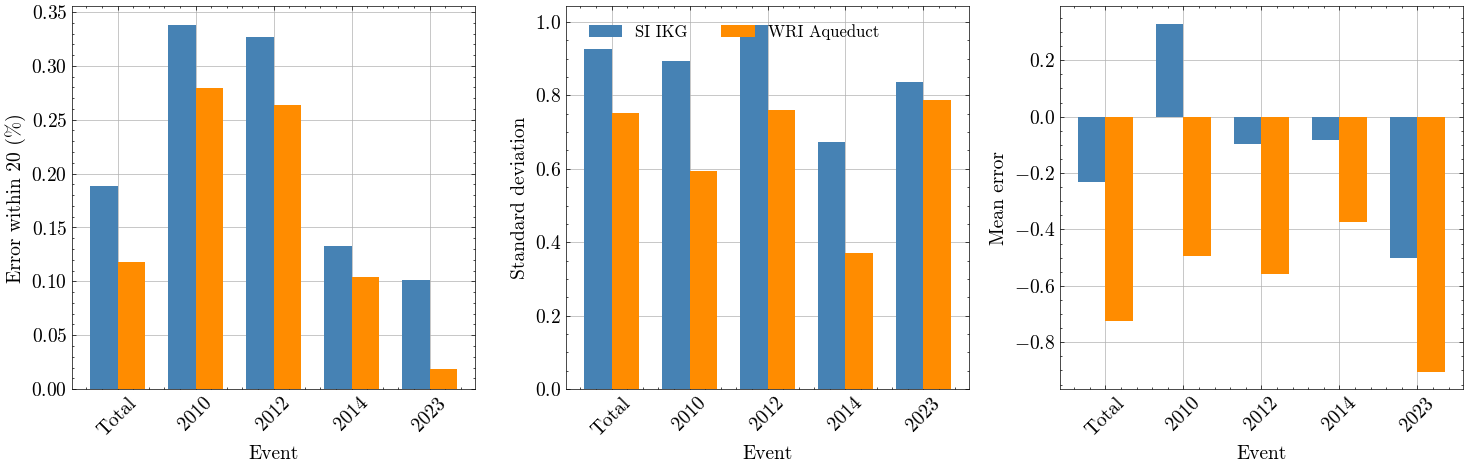

In [110]:
_df = df.copy()
_df2 = df.copy()#.head(1000)
# _df = _df[_df["distance_to_water"]<100]

# fig = plot_quality_metrics(_df, events, figtitle="Quality Metrics for SI and WRI Depth Predictions - Base Model, All Events")
# fig = plot_quality_metrics(_df, events)
fig = plot_quality_metrics(_df, events)#, df_water_proximity=_df2)#, figtitle="Quality Metrics for SI and WRI Depth Predictions - Base Model, All Events")
# plt.savefig(IMAGES_PATH + "/05/regression_metrics_raw.pdf", dpi=300, bbox_inches="tight")
# Add legend to the figure

# Proximity to water analysis

Total
{'si': {'within_20': 0.1882, 'median_error': -0.25, 'mean_error': -0.2314, 'median_absolute_error': 0.5, 'RMSE': 0.954, 'st_dev_residuals': 0.9255, 'total_samples': 11740}, 'wri': {'within_20': 0.1175, 'median_error': -0.5118, 'mean_error': -0.7238, 'median_absolute_error': 0.6, 'RMSE': 1.0429, 'st_dev_residuals': 0.7508, 'total_samples': 11740}, 'si_water_proximity': {'within_20': 0.1986, 'median_error': -0.2, 'mean_error': -0.1506, 'median_absolute_error': 0.5, 'RMSE': 0.935, 'st_dev_residuals': 0.9229, 'total_samples': 6691}, 'wri_water_proximity': {'within_20': 0.1109, 'median_error': -0.5674, 'mean_error': -0.7226, 'median_absolute_error': 0.6, 'RMSE': 1.0336, 'st_dev_residuals': 0.7391, 'total_samples': 6691}}
Event: 2010
{'si': {'within_20': 0.3383, 'median_error': 0.35, 'mean_error': 0.3295, 'median_absolute_error': 0.5, 'RMSE': 0.9516, 'st_dev_residuals': 0.8929, 'total_samples': 2477}, 'wri': {'within_20': 0.2794, 'median_error': -0.35, 'mean_error': -0.4929, 'median_ab

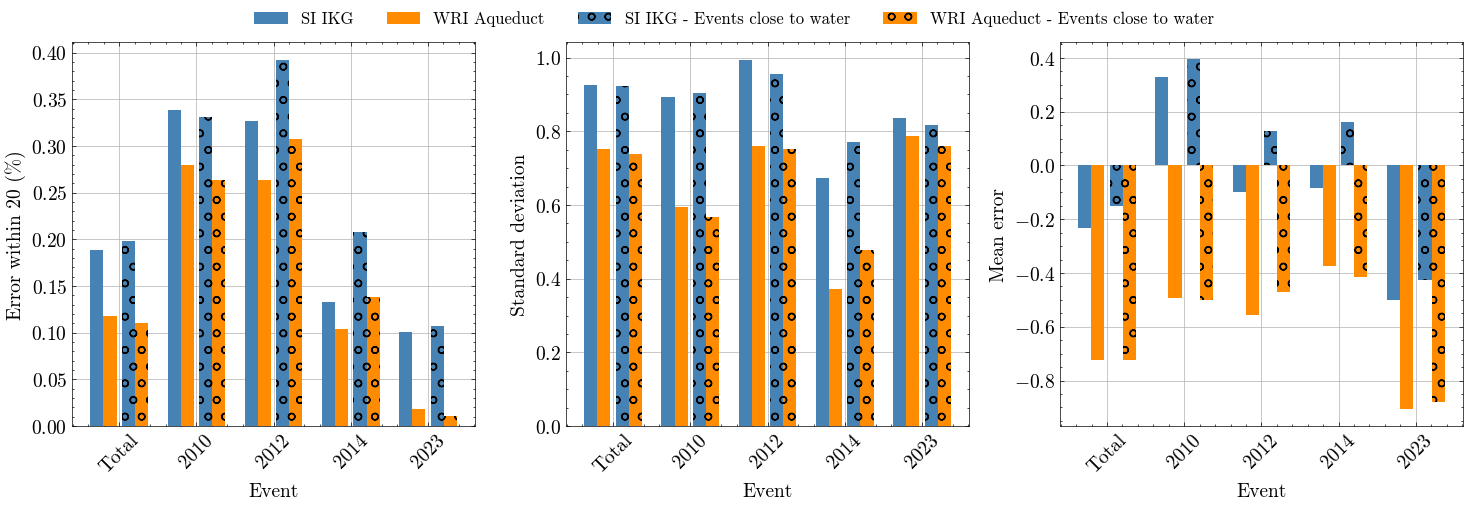

In [ ]:
_df = df.copy()
_df_closer_100m = _df[_df["distance_to_water"]<100].copy()

fig = plot_quality_metrics(_df, events, df_water_proximity=_df_closer_100m)#, figtitle="Quality Metrics for SI and WRI Depth Predictions - Base Model, Distance to Water < 100m")

# plt.savefig(IMAGES_PATH + "/05/regression_metrics_100m.pdf", dpi=300, bbox_inches="tight")

In [41]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_quality_metrics_proximity_to_water(df, events, bias_adjusted: bool = False, figtitle: str = None):
    """
    Create a plot showing different quality metrics for SI and WRI depth predictions.
    
    Args:
        df (pd.DataFrame): DataFrame containing the data
        events (list): List of event IDs to analyze
    """
    # Create figure
    fig, ax1 = plt.subplots(figsize=(10, 5))
    if figtitle:
        fig.suptitle(figtitle)

    predicted_col_si = "predicted_si_depth_bias_adjusted" if bias_adjusted else "predicted_si_depth"
    predicted_col_wri = "predicted_wri_depth_bias_adjusted" if bias_adjusted else "predicted_wri_depth"
    
    # Prepare data for plotting
    metrics = {
        "Total": {
            "si": quality_metrics.get_metrics(df["measured_depth"], df[predicted_col_si]),
            "wri": quality_metrics.get_metrics(df["measured_depth"], df[predicted_col_wri])
        }
    }
    
    for event_label in events:
        _df = df[df["DogodekLabel"] == event_label]
        metrics[event_label] = {
            "si": quality_metrics.get_metrics(_df["measured_depth"], _df[predicted_col_si]),
            "wri": quality_metrics.get_metrics(_df["measured_depth"], _df[predicted_col_wri])
        }
        print(metrics[event_label])
    
    # Extract metrics for plotting
    event_labels = list(metrics.keys())
    si_error_within_20 = [m["si"]["within_20"] for m in metrics.values()]
    wri_error_within_20 = [m["wri"]["within_20"] for m in metrics.values()]
    si_median_error = [m["si"]["median_error"] for m in metrics.values()]
    wri_median_error = [m["wri"]["median_error"] for m in metrics.values()]
    
    # Plot: Error within 20 and Median Error
    x = np.arange(len(event_labels))
    width = 0.35
    ax1.bar(x - width/2, si_error_within_20, width, label="SI Error within 20", color='b')
    ax1.bar(x + width/2, wri_error_within_20, width, label="WRI Error within 20", color='g')
    ax1.set_ylabel("Error within 20 (%)")
    ax1.set_xlabel("Event")
    ax1.set_xticks(x)
    ax1.set_xticklabels(event_labels, rotation=45)
    ax1.legend(loc='upper left')
    ax1.grid()

    # Create a second y-axis for median error
    ax2 = ax1.twinx()
    ax2.plot(x, si_median_error, label="SI Median Error", color='r', marker='o')
    ax2.plot(x, wri_median_error, label="WRI Median Error", color='y', marker='o')
    ax2.set_ylabel("Median Error")
    ax2.legend(loc='upper right')

    plt.tight_layout()
    return fig

In [42]:
# Create 4 buckets of distance to water
df["distance_to_water_bucket"] = pd.cut(df["distance_to_water"], bins=[0, 100, 200, 300], labels=[100, 200, 300])
df["distance_to_water_bucket"].value_counts()
# Nan values
# df["distance_to_water_bucket"].isna().sum()


distance_to_water_bucket
100    6016
200    2631
300     887
Name: count, dtype: int64

In [43]:
df[df["distance_to_water"]>300].shape


(1003, 18)

Bucket, distance to water:  100
{'si': {'within_20': 0.1028, 'median_error': 0.2, 'mean_error': 0.219, 'median_absolute_error': 0.61, 'RMSE': 0.9185, 'st_dev_residuals': 0.8925, 'total_samples': 1021}, 'wri': {'within_20': 0.0127, 'median_error': -0.5618, 'mean_error': -0.6865, 'median_absolute_error': 0.5617725729942322, 'RMSE': 0.8741, 'st_dev_residuals': 0.5414, 'total_samples': 1021}}
{'si': {'within_20': 0.1399, 'median_error': -0.1, 'mean_error': -0.1063, 'median_absolute_error': 0.5, 'RMSE': 0.9555, 'st_dev_residuals': 0.9503, 'total_samples': 679}, 'wri': {'within_20': 0.0206, 'median_error': -0.6, 'mean_error': -0.6856, 'median_absolute_error': 0.6, 'RMSE': 1.0433, 'st_dev_residuals': 0.7869, 'total_samples': 679}}
{'si': {'within_20': 0.0836, 'median_error': 0.0, 'mean_error': 0.0939, 'median_absolute_error': 0.4, 'RMSE': 0.7608, 'st_dev_residuals': 0.7564, 'total_samples': 275}, 'wri': {'within_20': 0.0036, 'median_error': -0.4, 'mean_error': -0.4834, 'median_absolute_error'

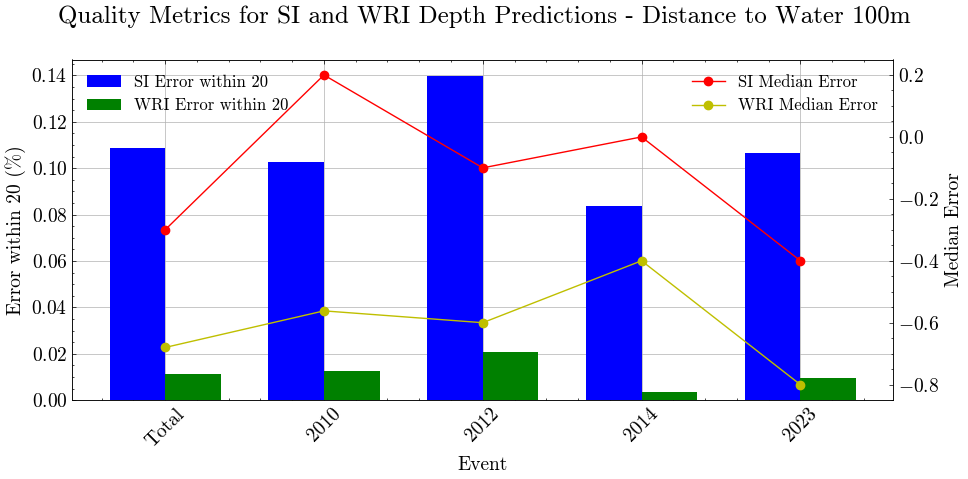

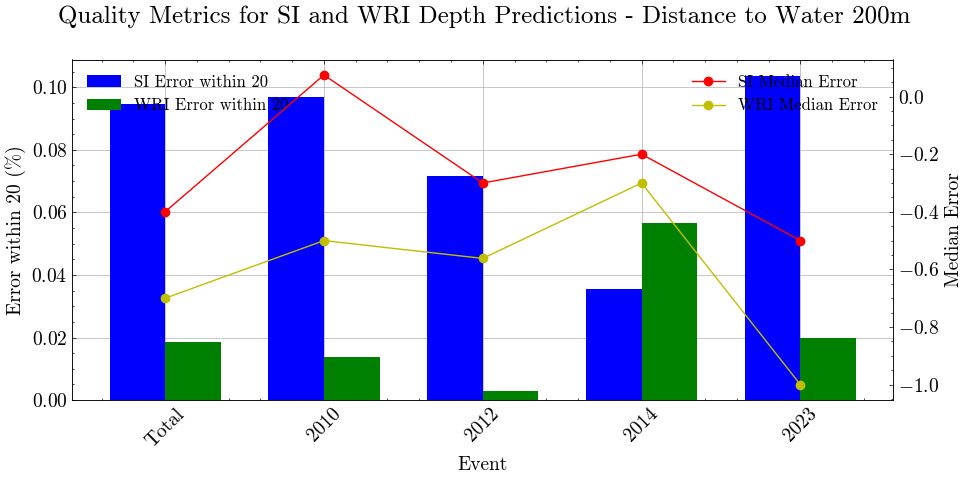

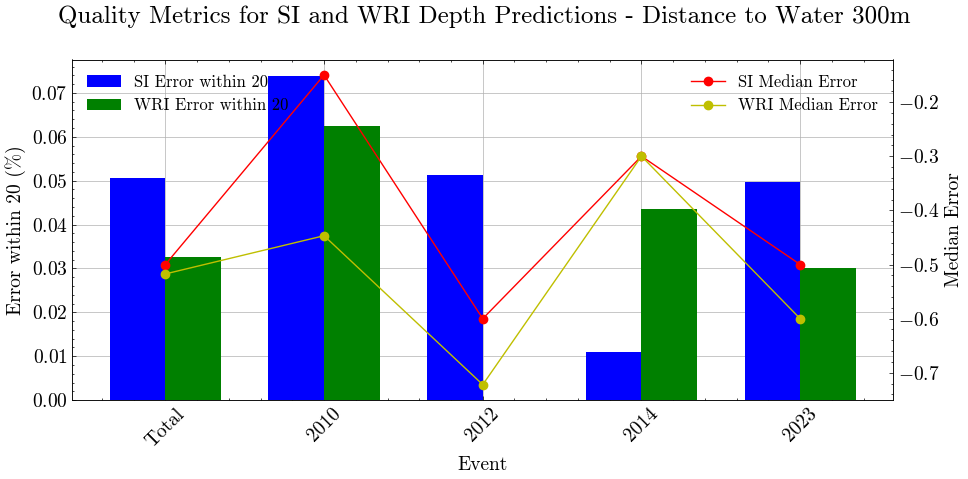

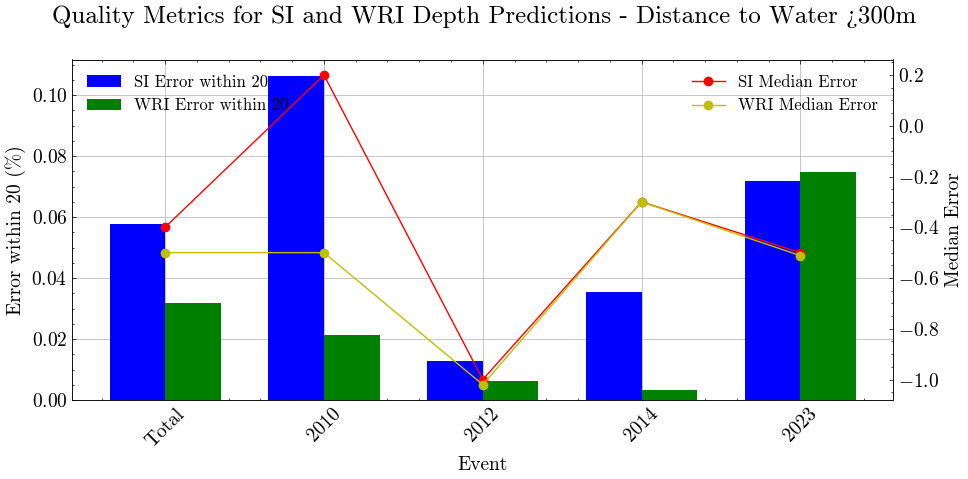

In [44]:
_df = df.copy()
for bucket in [100, 200, 300, ">300"]:
    if bucket == ">300":
        _df = df[df["distance_to_water"]>300]
    else:
        _df = df[df["distance_to_water_bucket"] == bucket]
    print("Bucket, distance to water: ", bucket)
    fig = plot_quality_metrics_proximity_to_water(_df, events, figtitle=f"Quality Metrics for SI and WRI Depth Predictions - Distance to Water {bucket}m")

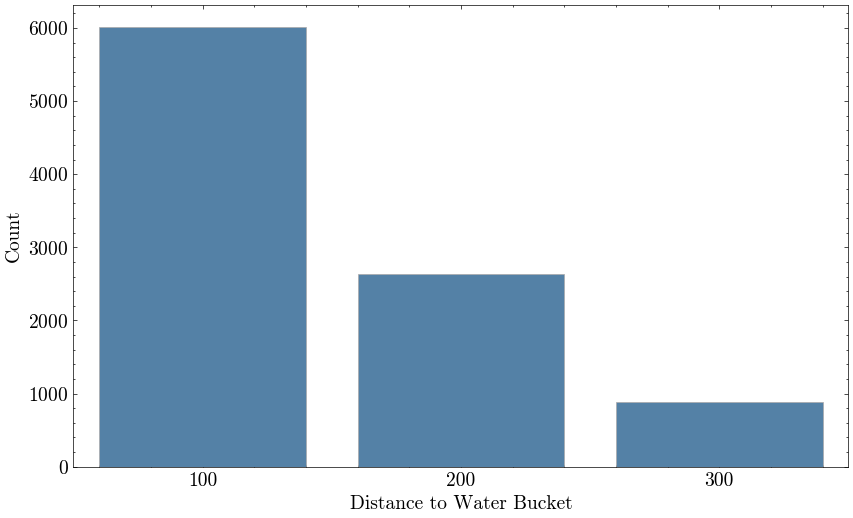

In [45]:
# Plot count by distance_to_water_bucket
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="distance_to_water_bucket", color="steelblue", edgecolor="darkgrey", linewidth=0.5)
plt.xlabel("Distance to Water Bucket")
plt.ylabel("Count")
plt.show()


In [46]:
# T-test analysis: Testing if water proximity significantly affects prediction performance
from scipy import stats

# Calculate absolute error for each model
df["si_abs_error"] = np.abs(df["si_error"])
df["wri_abs_error"] = np.abs(df["wri_error"])

# Split into two groups: close to water (<100m) vs far from water (>=100m)
close_to_water = df[df["distance_to_water"] < 100]
far_from_water = df[df["distance_to_water"] >= 100]

print("="*80)
print("T-TEST: Testing if water proximity significantly affects prediction performance")
print("="*80)
print(f"\nSplit threshold: 100m")
print(f"Close to water (<100m): n={len(close_to_water):,}")
print(f"Far from water (>=100m): n={len(far_from_water):,}")
print()

# Perform t-tests for both models
for model_name, error_col in [("SI IKG", "si_abs_error"), ("WRI Aqueduct", "wri_abs_error")]:
    print(f"\n{model_name}:")
    print("-" * 80)
    
    # Get absolute errors for each group
    close_errors = close_to_water[error_col].dropna()
    far_errors = far_from_water[error_col].dropna()
    
    # Descriptive statistics
    print(f"  Close to water (<100m):")
    print(f"    Mean MAE: {close_errors.mean():.4f}m")
    print(f"    Std Dev:  {close_errors.std():.4f}m")
    print(f"  Far from water (>=100m):")
    print(f"    Mean MAE: {far_errors.mean():.4f}m")
    print(f"    Std Dev:  {far_errors.std():.4f}m")
    
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(close_errors, far_errors)
    
    print(f"\n  Two-sample t-test results:")
    print(f"    t-statistic: {t_stat:.4f}")
    print(f"    p-value:     {p_value:.6f}")
    print(f"    Significant: {'Yes' if p_value < 0.05 else 'No'} (α=0.05)")
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt(((len(close_errors) - 1) * close_errors.std()**2 + 
                           (len(far_errors) - 1) * far_errors.std()**2) / 
                          (len(close_errors) + len(far_errors) - 2))
    cohens_d = (close_errors.mean() - far_errors.mean()) / pooled_std
    print(f"    Effect size (Cohen's d): {cohens_d:.4f}")
    
    # Interpretation
    if abs(cohens_d) < 0.2:
        effect_size = "negligible"
    elif abs(cohens_d) < 0.5:
        effect_size = "small"
    elif abs(cohens_d) < 0.8:
        effect_size = "medium"
    else:
        effect_size = "large"
    print(f"    Effect size: {effect_size}")

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)
print("A non-significant p-value (p > 0.05) indicates that water proximity does")
print("NOT significantly affect prediction performance. The models perform")
print("similarly regardless of distance to water bodies.")
print("="*80)

T-TEST: Testing if water proximity significantly affects prediction performance

Split threshold: 100m
Close to water (<100m): n=6,016
Far from water (>=100m): n=4,521


SI IKG:
--------------------------------------------------------------------------------
  Close to water (<100m):
    Mean MAE: 0.7147m
    Std Dev:  0.5771m
  Far from water (>=100m):
    Mean MAE: 0.7678m
    Std Dev:  0.6284m

  Two-sample t-test results:
    t-statistic: -4.5049
    p-value:     0.000007
    Significant: Yes (α=0.05)
    Effect size (Cohen's d): -0.0887
    Effect size: negligible

WRI Aqueduct:
--------------------------------------------------------------------------------
  Close to water (<100m):
    Mean MAE: 0.8676m
    Std Dev:  0.6574m
  Far from water (>=100m):
    Mean MAE: 0.8609m
    Std Dev:  0.7070m

  Two-sample t-test results:
    t-statistic: 0.5042
    p-value:     0.614131
    Significant: No (α=0.05)
    Effect size (Cohen's d): 0.0099
    Effect size: negligible

CONCLUSION:
A

# Model Resolution Analysis

In [47]:
df.head()

,VlogaId,DogodekId,DogodekLabel,gps_lat,gps_lng,measured_depth,predicted_wri_depth,predicted_si_depth,predicted_si_depth_100r,predicted_si_depth_1000r,distance_to_water,si_error,wri_error,si_error_100r,si_error_1000r,predicted_si_depth_bias_adjusted,predicted_wri_depth_bias_adjusted,distance_to_water_bucket,si_abs_error,wri_abs_error
0,147651,14,2010,45.555094,13.786126,0.3,0.000000,1.5,0.5,1.5,51.774728,1.2,-0.300000,0.2,1.2,1.340165,0.689922,100,1.2,0.300000
1,147686,14,2010,45.554893,13.785861,0.5,0.000000,0.5,0.5,1.5,77.397335,0.0,-0.500000,0.0,1.0,0.340165,0.689922,100,0.0,0.500000
2,147692,14,2010,45.554893,13.785861,0.5,0.000000,0.5,0.5,1.5,77.397335,0.0,-0.500000,0.0,1.0,0.340165,0.689922,100,0.0,0.500000
3,147704,14,2010,45.555094,13.786126,0.4,0.000000,1.5,0.5,1.5,51.774728,1.1,-0.400000,0.1,1.1,1.340165,0.689922,100,1.1,0.400000
4,147723,14,2010,45.562016,13.756194,1.3,0.482443,2.5,2.5,2.5,455.622715,1.2,-0.817557,1.2,1.2,2.340165,1.172364,NaN,1.2,0.817557


In [48]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_quality_metrics_resolution(df, events, bias_adjusted: bool = False, figtitle: str = None, si_resolution: int = 10):
    """
    Create three plots showing different quality metrics for different model resolutions of SI IKG models.
    The attributes columns to look at are:
    - predicted_si_depth
    - predicted_si_depth_100r
    - predicted_si_depth_1000r
    
    Args:
        df (pd.DataFrame): DataFrame containing the data
        events (list): List of event IDs to analyze
    """
    # Create figure with 3 subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    if figtitle:
        fig.suptitle(figtitle)

    # predicted_col_si = "predicted_si_depth_bias_adjusted" if bias_adjusted else "predicted_si_depth"
    # predicted_col_wri = "predicted_wri_depth_bias_adjusted" if bias_adjusted else "predicted_wri_depth"

    predicted_cols = [
        "predicted_si_depth",
        "predicted_si_depth_100r",
        "predicted_si_depth_1000r"
    ]
    # Prepare data for plotting
    metrics = {
        "Total": {
            f"{predicted_col}": quality_metrics.get_metrics(df["measured_depth"], df[predicted_col])
            for predicted_col in predicted_cols
        }
    }
    print(f"Total")
    print(metrics["Total"])
    
    for event_label in events:
        _df = df[df["DogodekLabel"] == event_label]
        metrics[event_label] = {
            f"{predicted_col}": quality_metrics.get_metrics(_df["measured_depth"], _df[predicted_col])
            for predicted_col in predicted_cols
        }
        print(f"Event: {event_label}")
        print(metrics[event_label])
    
    # Extract metrics for plotting
    event_labels = list(metrics.keys())

    predicted_si_depth_err20 = [m["predicted_si_depth"]["within_20"] for m in metrics.values()]
    predicted_si_depth_100r_err20 = [m["predicted_si_depth_100r"]["within_20"] for m in metrics.values()]
    predicted_si_depth_1000r_err20 = [m["predicted_si_depth_1000r"]["within_20"] for m in metrics.values()]

    predicted_si_depth_mean_error = [m["predicted_si_depth"]["mean_error"] for m in metrics.values()]
    predicted_si_depth_100r_mean_error = [m["predicted_si_depth_100r"]["mean_error"] for m in metrics.values()]
    predicted_si_depth_1000r_mean_error = [m["predicted_si_depth_1000r"]["mean_error"] for m in metrics.values()]

    predicted_si_depth_std_error = [m["predicted_si_depth"]["st_dev_residuals"] for m in metrics.values()]
    predicted_si_depth_100r_std_error = [m["predicted_si_depth_100r"]["st_dev_residuals"] for m in metrics.values()]
    predicted_si_depth_1000r_std_error = [m["predicted_si_depth_1000r"]["st_dev_residuals"] for m in metrics.values()]
    
    # Plot 1: Error within 20
    x = np.arange(len(event_labels))
    width = 0.20
    ax1.bar(x - width, predicted_si_depth_err20, width, label="SI IKG - 10m resolution", color="steelblue")
    ax1.bar(x, predicted_si_depth_100r_err20, width, label="SI IKG - 100m resolution", color="darkorange")
    ax1.bar(x + width, predicted_si_depth_1000r_err20, width, label="SI IKG - 1000m resolution", color="darkgreen")
    ax1.set_ylabel("Error within 20 (%)")
    ax1.set_xlabel("Event")
    ax1.set_xticks(x)
    ax1.set_xticklabels(event_labels, rotation=45)
    # ax1.legend()
    ax1.grid()

    # Plot 2: Standard Deviation
    ax2.bar(x - width, predicted_si_depth_std_error, width, label="predicted_si_depth_std_error", color="steelblue")
    ax2.bar(x, predicted_si_depth_100r_std_error, width, label="predicted_si_depth_100r_std_error", color="darkorange")
    ax2.bar(x + width, predicted_si_depth_1000r_std_error, width, label="predicted_si_depth_1000r_std_error", color="darkgreen")
    ax2.set_ylabel("Standard deviation")
    ax2.set_xlabel("Event")
    ax2.set_xticks(x)
    ax2.set_xticklabels(event_labels, rotation=45)
    # ax2.legend()
    ax2.grid()

    # Plot 3: mean_error
    ax3.bar(x - width, predicted_si_depth_mean_error, width, label="predicted_si_depth_mean_error", color="steelblue")
    ax3.bar(x, predicted_si_depth_100r_mean_error, width, label="predicted_si_depth_100r_mean_error", color="darkorange")
    ax3.bar(x + width, predicted_si_depth_1000r_mean_error, width, label="predicted_si_depth_1000r_mean_error", color="darkgreen")
    ax3.set_ylabel("Mean error")
    ax3.set_xlabel("Event")
    ax3.set_xticks(x)
    ax3.set_xticklabels(event_labels, rotation=45)
    # ax3.legend()
    ax3.grid()

    handles, labels_ = ax1.get_legend_handles_labels()
    # Add background color, border, and set a stronger frame to the legend
    legend = fig.legend(
        handles, labels_, loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=3, 
        facecolor="white", edgecolor="black", framealpha=1, frameon=True
    )
    legend.get_frame().set_linewidth(1.5)
    legend.get_frame().set_facecolor("#f9f9f9")  # Light background

    print(metrics)
    # Display your metrics in a clean table
    print("FLOOD DEPTH PREDICTION METRICS")
    print("="*50)
    # metrics_df = display_metrics_table(metrics)
    # print(metrics_df.to_string(index=False))

    # Or use the formatted summary
    # print_metrics_summary(metrics)

    plt.tight_layout()
    return fig

Total
{'predicted_si_depth': {'within_20': 0.0955, 'median_error': -0.3, 'mean_error': -0.3359, 'median_absolute_error': 0.55, 'RMSE': 0.9508, 'st_dev_residuals': 0.8896, 'total_samples': 10537}, 'predicted_si_depth_100r': {'within_20': 0.1171, 'median_error': -0.1, 'mean_error': -0.0115, 'median_absolute_error': 0.6000000000000001, 'RMSE': 1.0043, 'st_dev_residuals': 1.0042, 'total_samples': 10537}, 'predicted_si_depth_1000r': {'within_20': 0.0643, 'median_error': -0.4, 'mean_error': -0.3203, 'median_absolute_error': 0.7, 'RMSE': 1.1076, 'st_dev_residuals': 1.0603, 'total_samples': 10537}}
Event: 2010
{'predicted_si_depth': {'within_20': 0.099, 'median_error': 0.1, 'mean_error': 0.1598, 'median_absolute_error': 0.6000000000000001, 'RMSE': 0.9111, 'st_dev_residuals': 0.8973, 'total_samples': 1819}, 'predicted_si_depth_100r': {'within_20': 0.0852, 'median_error': 0.7, 'mean_error': 0.5815, 'median_absolute_error': 0.9, 'RMSE': 1.1276, 'st_dev_residuals': 0.9663, 'total_samples': 1819}, 

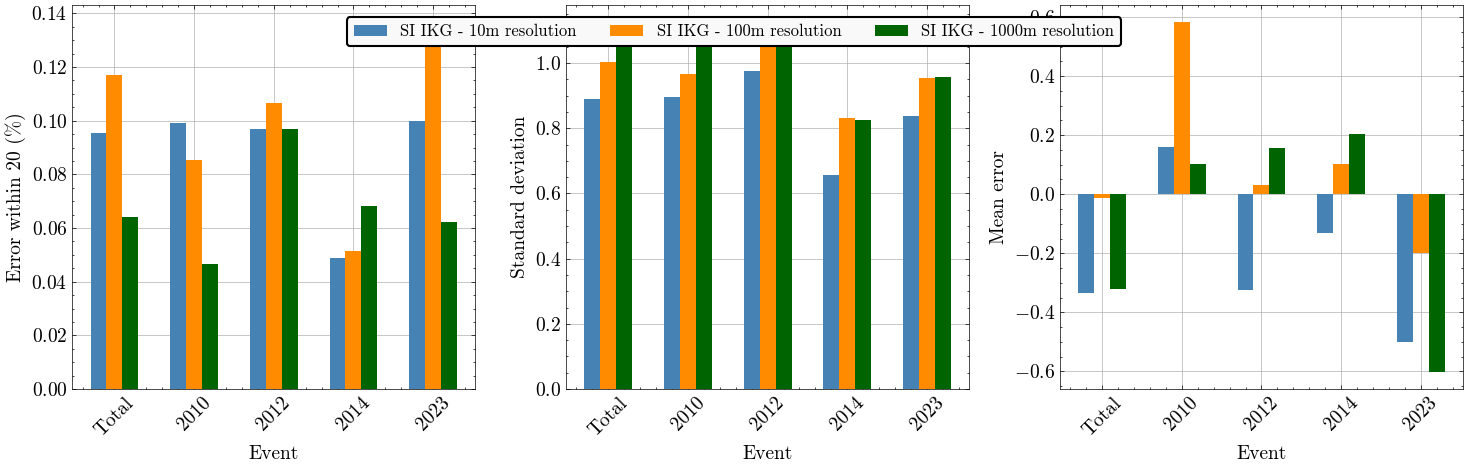

In [49]:
_df = df.copy()
# _df = _df[_df["distance_to_water"]<100]

fig = plot_quality_metrics_resolution(_df, events, si_resolution=100)

----------

# Categorize measured_depth into 4 categories


In [36]:
df["depth_category"] = pd.cut(df["measured_depth"], bins=[0, 0.5, 1.5, 2.5], labels=[0.5, 1.5, 2.5])
# df.shape
# df.head()
# df.groupby("depth_category").mean()
# df.groupby("depth_category").mean()

In [37]:
df["depth_category"].value_counts().sort_index()


depth_category
0.5    4277
1.5    4334
2.5    1757
Name: count, dtype: int64

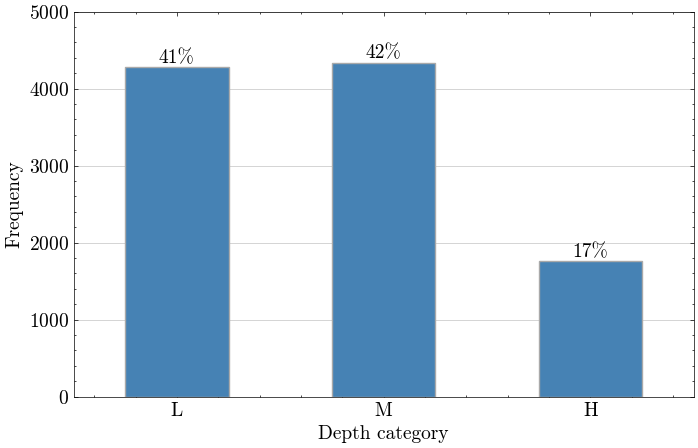

In [38]:
value_counts = df["depth_category"].value_counts().sort_index()
value_counts.plot(kind="bar", edgecolor="darkgrey", color="steelblue", figsize=(8, 5))


# Calculate relative percentages
total_count = value_counts.sum()
percentages = (value_counts / total_count) * 100

# Add text with percentages below the title
# percent_text = ", ".join([f"{cat}: {count} ({percent:.0f}%)" for cat, count, percent in zip(value_counts.index, value_counts, percentages)])
# plt.title(f"Histogram of Depth Category Counts\n{percent_text}")

plt.xlabel("Depth category")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)

# Change labels to L, M, H
plt.xticks(range(len(value_counts)), ["L", "M", "H"], rotation=0)
plt.ylim(0, 5000)

# Add % to the chart its on top of the bars
for i, (cat, v) in enumerate(value_counts.items()):
    plt.text(i, v + 10, f"{percentages[cat]:.0f}%", ha="center", va="bottom")

plt.savefig(IMAGES_PATH + "/05/validation_depth_classes.pdf", dpi=300, bbox_inches="tight")
plt.show()

<Axes: xlabel='depth_category', ylabel='predicted_si_depth'>

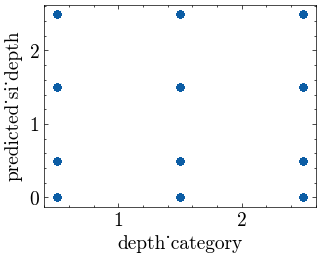

In [39]:
df.plot(x="depth_category", y="predicted_si_depth", kind="scatter")

In [40]:
def plot_confusion_matrix(df, true_column, predicted_column, title: str = "Confusion matrix"):
    # First, let's bin the measured_depth into categories and do the same for predictions
    # Create categorical bins for the depths
    def categorize_depth(depth):
        if depth <= 0.5:
            return "0.5"
        elif depth <= 1.5:
            return "1.5"
        return "2.5"
    
    _df = df.copy()
    
    _df["depth_category_true"] = _df[true_column].apply(categorize_depth)
    _df["depth_category_pred"] = _df[predicted_column].apply(categorize_depth)

    # Calculate confusion matrix
    cm = confusion_matrix(_df["depth_category_true"], _df["depth_category_pred"])
    categories = ["S", "M", "H"]

    # Plot the confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=categories, 
                yticklabels=categories)
    # plt.title(title)
    plt.xlabel("Predicted category")
    plt.ylabel("True category")
    # plt.show()

    # ---
    # Calculate metrics
    # ---
    accuracy = accuracy_score(_df["depth_category_true"], _df["depth_category_pred"])
    precision, recall, f1, support = precision_recall_fscore_support(
        _df["depth_category_true"], 
        _df["depth_category_pred"],
        labels=["0.5", "1.5", "2.5"],
        average=None
    )

    # Calculate additional multiclass metrics
    macro_precision = precision_recall_fscore_support(
        _df["depth_category_true"], 
        _df["depth_category_pred"],
        labels=["0.5", "1.5", "2.5"],
        average="macro"
    )[0]
    
    macro_recall = precision_recall_fscore_support(
        _df["depth_category_true"], 
        _df["depth_category_pred"],
        labels=["0.5", "1.5", "2.5"],
        average="macro"
    )[1]
    
    macro_f1 = precision_recall_fscore_support(
        _df["depth_category_true"], 
        _df["depth_category_pred"],
        labels=["0.5", "1.5", "2.5"],
        average="macro"
    )[2]

    metrics_df = pd.DataFrame({
        "Category": ["0.5", "1.5", "2.5"],
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Support": support
    })

    # Print overall accuracy
    print(f"Overall Classification Accuracy: {accuracy:.3f}\n")

    # Print per-category metrics
    print("Per-category metrics:")
    print(metrics_df.to_string(index=False))

    # Print macro metrics
    print("\nMacro-averaged metrics:")
    print(f"Macro Precision: {macro_precision:.3f}")
    print(f"Macro Recall: {macro_recall:.3f}")
    print(f"Macro F1-Score: {macro_f1:.3f}")

    """
    Metrics explanation:
    - Accuracy: Proportion of correct predictions among total predictions
    - Precision: Proportion of correct positive predictions among all positive predictions for each category
    - Recall: Proportion of correct positive predictions among all actual positives for each category
    - F1-Score: Harmonic mean of precision and recall for each category
    - Support: Number of samples in each category
    - Macro Precision/Recall/F1-Score: Average of the precision/recall/f1-score for all categories
    """

WRI
Overall Classification Accuracy: 0.461

Per-category metrics:
Category  Precision   Recall  F1-Score  Support
     0.5   0.493299 0.779197  0.604131     5480
     1.5   0.388762 0.236271  0.293915     4334
     2.5   0.275556 0.064382  0.104377     1926

Macro-averaged metrics:
Macro Precision: 0.386
Macro Recall: 0.360
Macro F1-Score: 0.334


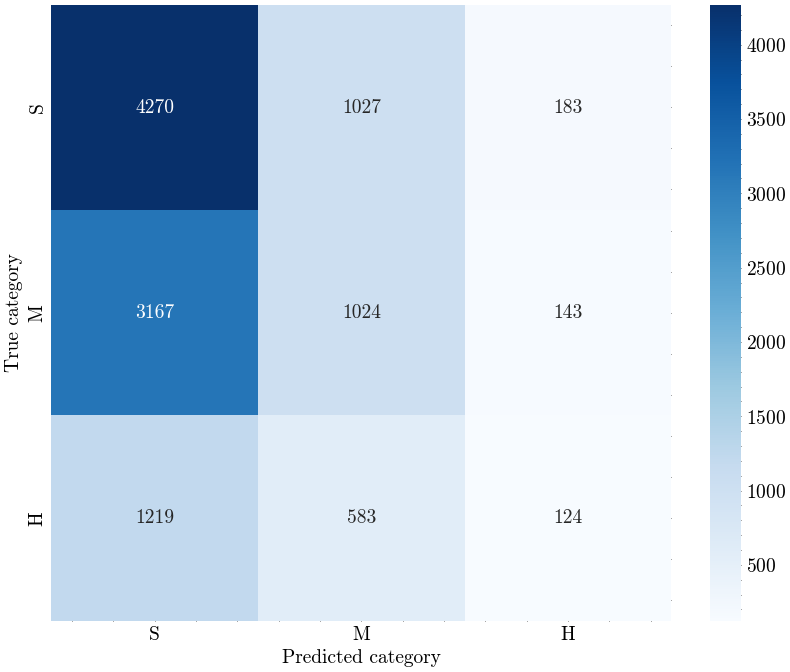

In [41]:
print("WRI")
plot_confusion_matrix(df, "measured_depth", "predicted_si_depth", title="Confusion Matrix [SI IKG]")

SI IKG - Bias Adjusted
Overall Classification Accuracy: 0.432

Per-category metrics:
Category  Precision   Recall  F1-Score  Support
     0.5   0.520014 0.559489  0.539030     5480
     1.5   0.373126 0.315874  0.342122     4334
     2.5   0.292414 0.330218  0.310168     1926

Macro-averaged metrics:
Macro Precision: 0.395
Macro Recall: 0.402
Macro F1-Score: 0.397


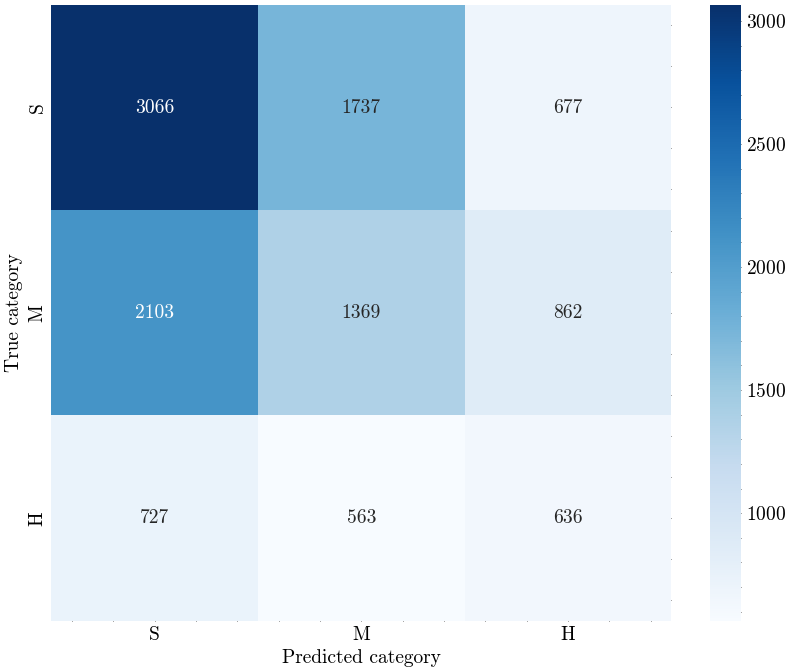

In [45]:
print("SI IKG - Bias Adjusted")
plot_confusion_matrix(df, "measured_depth", "predicted_si_depth_bias_adjusted", title="Confusion Matrix [SI IKG - Bias Adjusted]")
plt.savefig(IMAGES_PATH + "/05/confusion_matrix_si_ikg_bias_adjusted.pdf", dpi=300, bbox_inches="tight")

Overall Classification Accuracy: 0.464

Per-category metrics:
Category  Precision   Recall  F1-Score  Support
     0.5   0.468249 0.986314  0.635023     5480
     1.5   0.277778 0.003461  0.006837     4334
     2.5   0.209790 0.015576  0.029000     1926

Macro-averaged metrics:
Macro Precision: 0.319
Macro Recall: 0.335
Macro F1-Score: 0.224


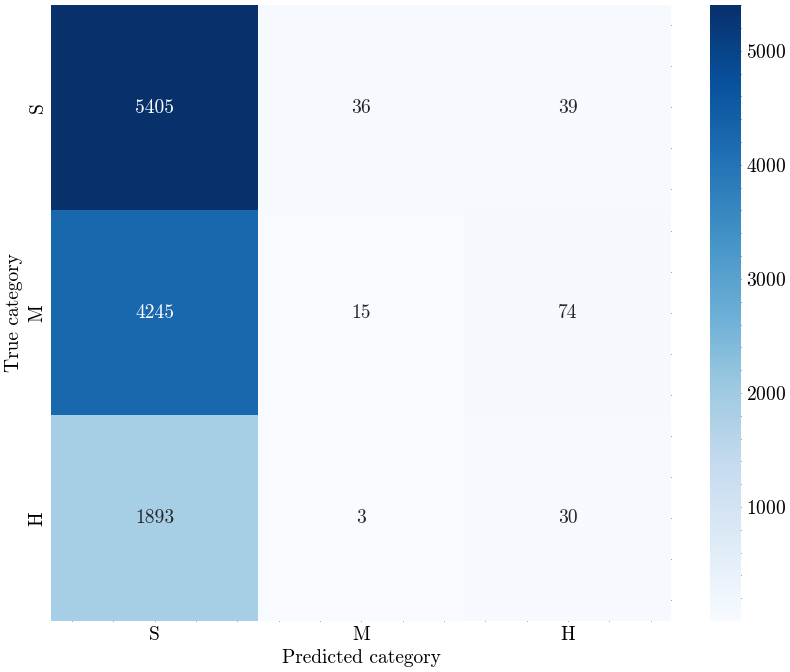

In [43]:
plot_confusion_matrix(df, "measured_depth", "predicted_wri_depth", title="Confusion Matrix [WRI]")

WRI - Bias Adjusted
Overall Classification Accuracy: 0.459

Per-category metrics:
Category  Precision   Recall  F1-Score  Support
     0.5   0.683244 0.325912  0.441315     5480
     1.5   0.397863 0.824642  0.536758     4334
     2.5   0.209790 0.015576  0.029000     1926

Macro-averaged metrics:
Macro Precision: 0.430
Macro Recall: 0.389
Macro F1-Score: 0.336


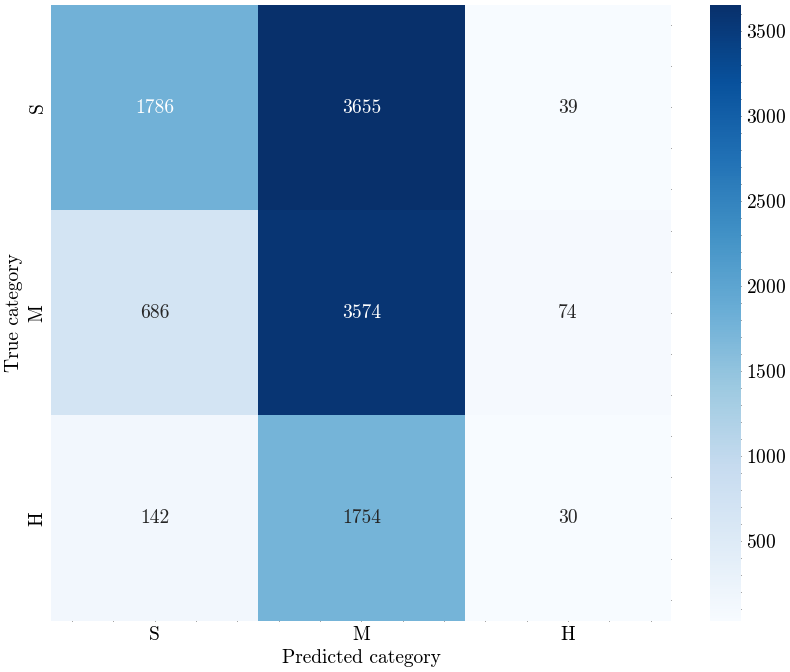

In [44]:
print("WRI - Bias Adjusted")
plot_confusion_matrix(df, "measured_depth", "predicted_wri_depth_bias_adjusted", title="Confusion Matrix [WRI - Bias Adjusted]")
plt.savefig(IMAGES_PATH + "/05/confusion_matrix_wri_bias_adjusted.pdf", dpi=300, bbox_inches="tight")

In [163]:
# Statistics

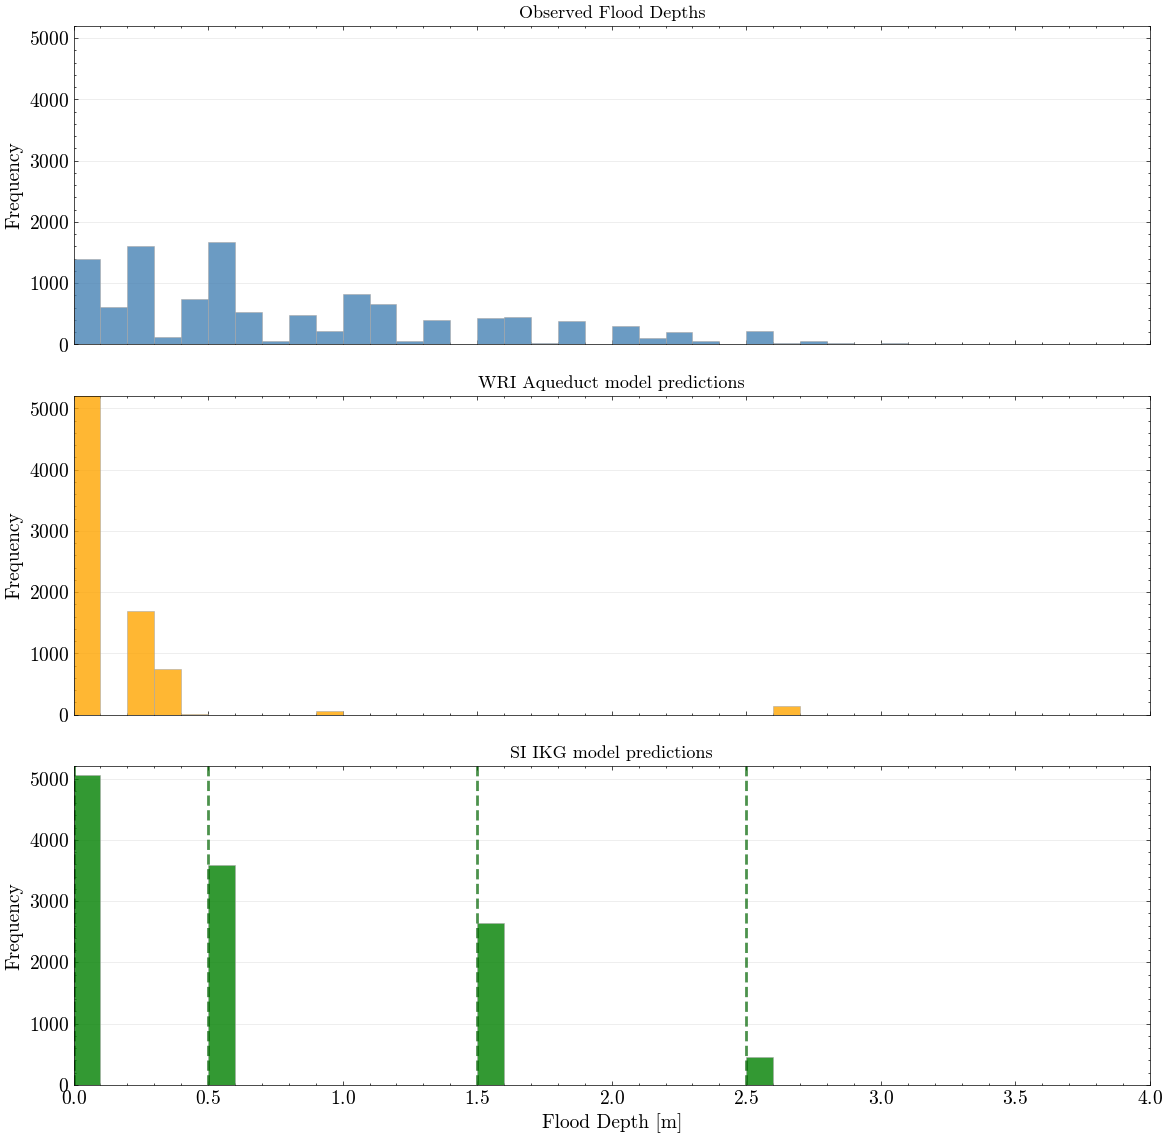

Model Performance Comparison:
--------------------------------------------------
Observed mean: 0.817m
Observed range: 0.00 - 3.95m
Observed length: 11740
WRI Model (Continuous):
  LEN: 11740
  AVG: 0.093m
  MAE: 0.781m
  RMSE: 1.043m
  Range: 0.00 - 4.75m

IKG Model (Discrete):
  LEN: 11740
  AVG: 0.585m
  MAE: 0.732m
  RMSE: 0.954m
  Discrete values: [0.0, 0.5, 1.5, 2.5]
  Value distribution: {0.0: 5063, 0.5: 3593, 1.5: 2634, 2.5: 450}


In [40]:
# Alternative visualization emphasizing discrete vs continuous nature
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Consistent bins for all three plots
bins = np.arange(0, 4.1, 0.1)

# Plot 1: Observed depths
ax1.hist(df["measured_depth"], bins=bins, alpha=0.8, color="steelblue", 
         edgecolor="darkgrey", linewidth=0.5)
ax1.set_ylabel("Frequency", fontsize=14)
ax1.set_title("Observed Flood Depths", fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
# ax1.text(0.02, 0.95, f"n={len(df['measured_depth'])}", transform=ax1.transAxes, 
#          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 2: WRI predictions (continuous)
ax2.hist(df["predicted_wri_depth"], bins=bins, alpha=0.8, color="orange", 
         edgecolor="darkgrey", linewidth=0.5)
ax2.set_ylabel("Frequency", fontsize=14)
ax2.set_title("WRI Aqueduct model predictions", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
# ax2.text(0.02, 0.95, f"Continuous distribution", transform=ax2.transAxes, 
#          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 3: IKG predictions (discrete) - use step plot to emphasize discrete nature
counts, bin_edges = np.histogram(df["predicted_si_depth"], bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

ax3.hist(df["predicted_si_depth"], bins=bins, alpha=0.8, color="green", 
         edgecolor="darkgrey", linewidth=0.5)

# Overlay discrete values as vertical lines to emphasize discrete nature
unique_values = sorted(df["predicted_si_depth"].unique())
for val in unique_values:
    count = (df["predicted_si_depth"] == val).sum()
    ax3.axvline(x=val, color='darkgreen', linestyle='--', alpha=0.7, linewidth=2)
    # ax3.text(val, count + 50, f'{val}m', ha='center', va='bottom', 
    #          fontsize=10, fontweight='bold', color='darkgreen')

ax3.set_ylabel("Frequency", fontsize=14)
ax3.set_xlabel("Flood Depth [m]", fontsize=14)
ax3.set_title("SI IKG model predictions", fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
# ax3.text(0.02, 0.95, f"Discrete values: {unique_values}", transform=ax3.transAxes, 
#          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

# Set common x-axis properties
for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0, 4)
    ax.set_xticks(np.arange(0, 4.5, 0.5))

_ylim = 5200
ax1.set_ylim(0, _ylim)
ax2.set_ylim(0, _ylim)
ax3.set_ylim(0, _ylim)

# plt.suptitle("Comparison of Flood Depth Distributions: Observed vs. WRI vs. IKG at RP100", 
#              fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.savefig(IMAGES_PATH + "/05/depth_distribution_histograms.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Statistical comparison
print("Model Performance Comparison:")
print("-" * 50)
observed = df["measured_depth"]
wri_pred = df["predicted_wri_depth"] 
ikg_pred = df["predicted_si_depth"]

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate metrics
wri_mae = mean_absolute_error(observed, wri_pred)
wri_rmse = np.sqrt(mean_squared_error(observed, wri_pred))
ikg_mae = mean_absolute_error(observed, ikg_pred)
ikg_rmse = np.sqrt(mean_squared_error(observed, ikg_pred))

print(f"Observed mean: {observed.mean():.3f}m")
print(f"Observed range: {observed.min():.2f} - {observed.max():.2f}m")
print(f"Observed length: {len(observed)}")

print(f"WRI Model (Continuous):")
print(f"  LEN: {len(wri_pred)}")
print(f"  AVG: {wri_pred.mean():.3f}m")
print(f"  MAE: {wri_mae:.3f}m")
print(f"  RMSE: {wri_rmse:.3f}m")
print(f"  Range: {wri_pred.min():.2f} - {wri_pred.max():.2f}m")

print(f"\nIKG Model (Discrete):")
print(f"  LEN: {len(ikg_pred)}")
print(f"  AVG: {ikg_pred.mean():.3f}m")
print(f"  MAE: {ikg_mae:.3f}m") 
print(f"  RMSE: {ikg_rmse:.3f}m")
print(f"  Discrete values: {unique_values}")
print(f"  Value distribution: {dict(df['predicted_si_depth'].value_counts().sort_index())}")



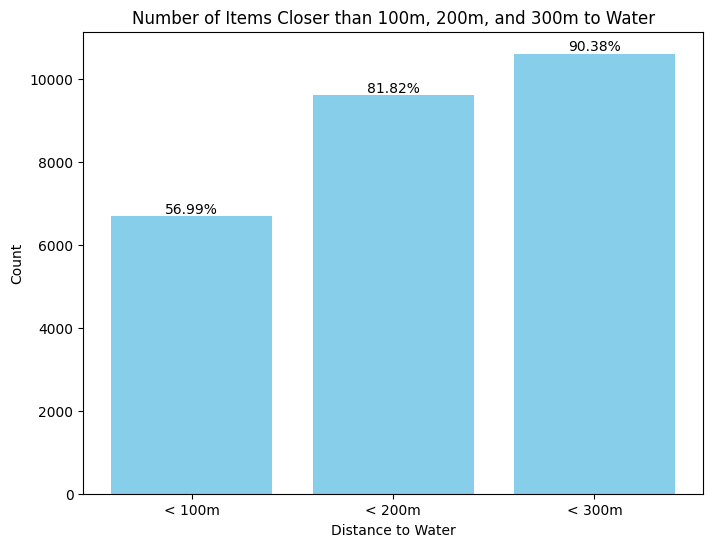

In [166]:
import matplotlib.pyplot as plt

# Define distance thresholds
distance_thresholds = [100, 200, 300]
close_items_counts = []
percentages_close_items = []

# Calculate counts and percentages for each threshold
total_items_count = df.shape[0]
for threshold in distance_thresholds:
    close_items = df[df["distance_to_water"] < threshold]
    close_items_count = close_items.shape[0]
    percentage_close_items = (close_items_count / total_items_count) * 100
    close_items_counts.append(close_items_count)
    percentages_close_items.append(percentage_close_items)

# Plot the results
plt.figure(figsize=(8, 6))
plt.bar([f"< {threshold}m" for threshold in distance_thresholds], close_items_counts, color="skyblue")
plt.title("Number of Items Closer than 100m, 200m, and 300m to Water")
plt.ylabel("Count")
plt.xlabel("Distance to Water")

# Annotate the bars with the percentages
for i, (count, percentage) in enumerate(zip(close_items_counts, percentages_close_items)):
    plt.text(i, count, f"{percentage:.2f}%", ha="center", va="bottom")

plt.show()
